# EduAnalytics — Fase 2: Comprensión de los datos
## Análisis exploratorio retrospectivo · CRISP-DM

**Universidad:** Universidad Privada Franz Tamayo (UNIFRANZ). **Materia:** Minería de Datos.

**Integrantes**, según el README local:
- Milenka Melody Chuquimia Osco
- Edson Teddy Tito Chuquimia
- Carlos Daniel Valverde Mendoza
- Alvaro Luis Carlos del Carpio Blanco
- Marcelo Josue Escobar Chipana

**Propósito:** comprender estructura, calidad, distribuciones y asociaciones del CSV utilizado
en la Fase 1 y dejar decisiones fundamentadas para la preparación de datos.

**Fuente única:** `dataset/ai_student_impact_dataset (1).csv`, ruta relativa a la raíz del proyecto.
Una fila representa un estudiante según la unidad declarada en la documentación. La población
estudiada son exclusivamente los estudiantes universitarios representados en este archivo.
UNIFRANZ identifica a la institución del equipo, no a la población de origen del CSV.

**Objetivo principal:** `Burnout_Risk_Level` con categorías `Low`, `Medium` y `High`.
El futuro problema es clasificación multiclase con interés especial en `High`.
El análisis es retrospectivo sobre los registros disponibles: no acredita detección anticipada.
La etiqueta no es un diagnóstico clínico. El dataset podría ser sintético o simulado y sus
asociaciones no prueban causalidad ni representatividad de toda la población universitaria.


## 1. Referencias, procedencia y reproducibilidad

Se utilizan únicamente los documentos de esta copia local:
[README](../../README.md), [información general](../../docs/INFORMACION_GENERAL_PROYECTO_EDUANALYTICS.md),
[entorno](../../docs/ENTORNO_PROYECTO.md) y
[Fase 1](../01_ENTENDIMIENTO_NEGOCIO/01_entendimiento_negocio.ipynb).
No se mezclan resultados de otros datasets ni de notebooks de ejemplo.

La publicación original, versión, publicador y licencia se verificaron: véase [procedencia](../../docs/PROCEDENCIA_DATASET.md). La fecha original de descarga, recolección, instrumentos y fórmula de etiqueta permanecen pendientes.

**Ejecución:** Python 3 y las bibliotecas de `requirements.txt`. Para automatizar una ejecución
desde cero y una exportación de revisión se requieren además `nbformat`, `nbclient` y `nbconvert`.
Ejecutar todas las celdas en orden desde un kernel limpio, con directorio de trabajo en la raíz
del repositorio o en la carpeta de este notebook. No se utiliza una ruta absoluta de un integrante.


In [1]:
from pathlib import Path
from decimal import Decimal, ROUND_HALF_UP
import ast
import csv
import hashlib
import io
import json
import re
import sys
import unicodedata

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

%matplotlib inline
assert sys.version_info[:3] == (3, 10, 6), "Usar Python 3.10.6."
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.02)
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 130})
CLASES = ['Low', 'Medium', 'High']
PALETA = {'Low': '#287D8E', 'Medium': '#D89B32', 'High': '#BA4452'}
RUTA_CSV = Path('dataset/ai_student_impact_dataset (1).csv')
RUTA_FASE1 = Path('wrangler/01_ENTENDIMIENTO_NEGOCIO/01_entendimiento_negocio.ipynb')
RUTA_DOC = Path('docs/INFORMACION_GENERAL_PROYECTO_EDUANALYTICS.md')
RAIZ = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'README.md').is_file() and (p / 'docs').is_dir()), None)
if RAIZ is None:
    raise FileNotFoundError('No se encontró la raíz: ejecutar desde el repositorio o la carpeta del notebook.')
requeridos = [Path('README.md'), RUTA_DOC, Path('docs/ENTORNO_PROYECTO.md'), RUTA_FASE1, RUTA_CSV]
faltan = [p.as_posix() for p in requeridos if not (RAIZ / p).is_file()]
if faltan:
    raise FileNotFoundError('Faltan archivos requeridos: ' + ', '.join(faltan) + '. No se calculan resultados sustitutos.')
documento = (RAIZ / RUTA_DOC).read_text(encoding='utf-8-sig')
readme = (RAIZ / 'README.md').read_text(encoding='utf-8-sig')
fase1 = json.loads((RAIZ / RUTA_FASE1).read_text(encoding='utf-8-sig'))
rutas_fase1 = []
for celda in fase1['cells']:
    if celda['cell_type'] == 'code':
        arbol = ast.parse(''.join(celda['source']))
        for nodo in ast.walk(arbol):
            if isinstance(nodo, ast.Assign) and any(isinstance(t, ast.Name) and t.id == 'RUTA_CSV' for t in nodo.targets):
                rutas_fase1.append(Path(ast.literal_eval(nodo.value.args[0])))
if rutas_fase1 != [RUTA_CSV]:
    raise ValueError(f'La ruta de Fase 1 ({rutas_fase1}) no coincide con {RUTA_CSV.as_posix()}; revisar antes de continuar.')
contenido = (RAIZ / RUTA_CSV).read_bytes()
huella_csv = hashlib.sha256(contenido).hexdigest()
salidas_fase1 = '\n'.join(''.join(o.get('text', [])) for c in fase1['cells'] for o in c.get('outputs', []))
huellas_fase1 = re.findall(r'SHA-256:\s*([a-f0-9]{64})', salidas_fase1)
df = pd.read_csv(io.BytesIO(contenido), sep=';', encoding='utf-8-sig', float_precision='round_trip')
lector_crudo = csv.DictReader(io.StringIO(contenido.decode('utf-8-sig')), delimiter=';')
filas_crudas = list(lector_crudo)
if any(None in fila or any(v is None for v in fila.values()) for fila in filas_crudas):
    raise ValueError('Hay filas con campos adicionales o faltantes: revisar la estructura CSV antes de analizar.')
crudo = pd.DataFrame(filas_crudas, columns=lector_crudo.fieldnames)
columnas_originales = tuple(df.columns)
forma_original = df.shape
firma_dataframe = pd.util.hash_pandas_object(df, index=True).values.copy()

def texto(mensaje):
    display(Markdown(mensaje))

def es(valor, decimales=2):
    return f'{valor:,.{decimales}f}'.replace(',', '_').replace('.', ',').replace('_', '.')

_numero_tabla = 0

def tabla(datos, precision=3):
    global _numero_tabla
    _numero_tabla += 1
    display(datos.style.set_uuid(f'eda_{_numero_tabla}').format(precision=precision, decimal=',', thousands='.', na_rep='No disponible')
            .set_properties(**{'text-align': 'left'})
            .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left'), ('vertical-align', 'top')]}]), exclude=['text/plain'])

def seccion(numero):
    patron = rf'^## {numero}\..*?(?=^## \d+\.|\Z)'
    resultado = re.search(patron, documento, flags=re.M | re.S)
    if resultado is None:
        raise ValueError(f'No se encontró la sección {numero} en {RUTA_DOC.as_posix()}.')
    return resultado.group(0)

print('CSV utilizado:', RUTA_CSV.as_posix())
print('CSV verificado contra código de Fase 1:', rutas_fase1[0].as_posix())
print('Separador: ; | Codificación: UTF-8 compatible con BOM')
print('SHA-256 actual:', huella_csv)
print('Huella guardada en Fase 1:', huellas_fase1 or 'pendiente: sin salida de huella')
print('Coincidencia de contenido:', huellas_fase1 == [huella_csv])
print('Versiones:', {'Python': sys.version.split()[0], 'pandas': pd.__version__, 'numpy': np.__version__,
                     'matplotlib': matplotlib.__version__, 'seaborn': sns.__version__})
if huellas_fase1 != [huella_csv]:
    raise ValueError('Ejecutar primero Fase 1: falta una huella vigente del mismo CSV.')
else:
    texto('**Trazabilidad:** la ruta coincide con la Fase 1. ' +
          ('La huella también coincide: se analiza el mismo contenido.' if huellas_fase1 else 'La identidad de contenido queda pendiente porque Fase 1 no guardó una huella.'))

procedencia = pd.DataFrame([
    ('Publicación y versión', 'AI Usage & Student Academic Performance Analysis; versión 1'),
    ('Enlace exacto', 'https://www.kaggle.com/datasets/ranaghulamnabi/ai-usage-and-student-academic-performance-analysis'),
    ('Publicador', 'ranaghulamnabi / Coding expert G.N; no acredita autor científico'),
    ('Licencia declarada', 'CC0: Public Domain'),
    ('Consulta y comparación', '2026-10-09; mismos 50.000 registros, 16 variables y valores'),
    ('Fecha de descarga original', 'Pendiente; la consulta actual no la sustituye'),
    ('Recolección, instrumentos o simulación', 'Pendientes; origen sintético no confirmado'),
    ('Muestreo, universidad y país', 'Pendientes; UNIFRANZ es la universidad del equipo'),
    ('Momentos de observación', 'Pendientes salvo definiciones pre/post publicadas'),
    ('Fórmula de Burnout_Risk_Level', 'Pendiente: umbrales, variables generadoras y validación'),
], columns=['Dato de procedencia', 'Estado'])
tabla(procedencia)


CSV utilizado: dataset/ai_student_impact_dataset (1).csv
CSV verificado contra código de Fase 1: dataset/ai_student_impact_dataset (1).csv
Separador: ; | Codificación: UTF-8 compatible con BOM
SHA-256 actual: 585c433cf9b447df6812c76dbb6732d2bb663689a7b595a9a4b5d777fea991d5
Huella guardada en Fase 1: ['585c433cf9b447df6812c76dbb6732d2bb663689a7b595a9a4b5d777fea991d5']
Coincidencia de contenido: True
Versiones: {'Python': '3.10.6', 'pandas': '2.3.3', 'numpy': '2.2.6', 'matplotlib': '3.10.9', 'seaborn': '0.13.2'}


**Trazabilidad:** la ruta coincide con la Fase 1. La huella también coincide: se analiza el mismo contenido.

,Dato de procedencia,Estado
0,Publicación y versión,AI Usage & Student Academic Performance Analysis; versión 1
1,Enlace exacto,https://www.kaggle.com/datasets/ranaghulamnabi/ai-usage-and-student-academic-performance-analysis
2,Publicador,ranaghulamnabi / Coding expert G.N; no acredita autor científico
3,Licencia declarada,CC0: Public Domain
4,Consulta y comparación,"2026-10-09; mismos 50.000 registros, 16 variables y valores"
5,Fecha de descarga original,Pendiente; la consulta actual no la sustituye
6,"Recolección, instrumentos o simulación",Pendientes; origen sintético no confirmado
7,"Muestreo, universidad y país",Pendientes; UNIFRANZ es la universidad del equipo
8,Momentos de observación,Pendientes salvo definiciones pre/post publicadas
9,Fórmula de Burnout_Risk_Level,"Pendiente: umbrales, variables generadoras y validación"


## 2. Estructura, muestra y diccionario de las 16 variables

Preguntas: ¿qué representa cada campo?, ¿qué escalas se observan?, ¿coinciden las dimensiones
y la unidad declaradas? Los tipos inferidos describen el archivo y se distinguen del papel metodológico.
Un identificador almacenado como entero sigue siendo un identificador.


In [2]:
DIMENSIONES_DOC = {'Filas': 50_000, 'Columnas': 16, 'Student_ID únicos': 50_000}
dimensiones = pd.DataFrame({'Documentado (docs §6)': DIMENSIONES_DOC,
                           'Observado': {'Filas': len(df), 'Columnas': df.shape[1],
                                         'Student_ID únicos': df['Student_ID'].nunique(dropna=True)}})
dimensiones['Diferencia'] = dimensiones['Observado'] - dimensiones['Documentado (docs §6)']
tabla(dimensiones, 0)
tabla(pd.DataFrame({'Variable': df.columns, 'Tipo observado': df.dtypes.astype(str).values}))
display(df.head(5).T.rename(columns=lambda i: f'Registro {i + 1}'))
texto(f'**Interpretación:** se leen {es(len(df), 0)} filas y {df.shape[1]} variables. ' +
      ('Las dimensiones y el número de identificadores únicos coinciden con docs.' if dimensiones['Diferencia'].eq(0).all()
       else 'Hay diferencias con docs; la tabla indica exactamente el conteo afectado. Revisar la versión del CSV, sin sustituirlo.') +
      ' La muestra ilustra el formato, no representa por sí sola toda la distribución. ' +
      'La unicidad del identificador es consistente con fila–estudiante; no confirma la existencia de personas reales.')


,Documentado (docs §6),Observado,Diferencia
Filas,50.000,50.000,0
Columnas,16,16,0
Student_ID únicos,50.000,50.000,0


,Variable,Tipo observado
0,Student_ID,int64
1,Major_Category,object
2,Year_of_Study,object
3,Pre_Semester_GPA,float64
4,Weekly_GenAI_Hours,float64
5,Primary_Use_Case,object
6,Prompt_Engineering_Skill,object
7,Tool_Diversity,int64
8,Paid_Subscription,bool
9,Traditional_Study_Hours,float64


,Registro 1,Registro 2,Registro 3,Registro 4,Registro 5
Student_ID,100001,100002,100003,100004,100005
Major_Category,Humanities,Medical,Business,Business,STEM
Year_of_Study,Senior,Junior,Freshman,Senior,Sophomore
Pre_Semester_GPA,2.418,3.821,3.398,3.789,3.635
Weekly_GenAI_Hours,23.31,1.12,21.26,1.82,9.29
Primary_Use_Case,Copywriting/Drafting,Ideation,Summarizing_Reading,Copywriting/Drafting,Debugging/Troubleshooting
Prompt_Engineering_Skill,Beginner,Advanced,Beginner,Intermediate,Advanced
Tool_Diversity,1,5,2,4,4
Paid_Subscription,True,False,False,False,False
Traditional_Study_Hours,8.13,16.65,10.35,15.23,12.55


**Interpretación:** se leen 50.000 filas y 16 variables. Las dimensiones y el número de identificadores únicos coinciden con docs. La muestra ilustra el formato, no representa por sí sola toda la distribución. La unicidad del identificador es consistente con fila–estudiante; no confirma la existencia de personas reales.

In [3]:
meta = {
    'Student_ID': ('Identificador del estudiante', 'ID', 'Identificador: trazabilidad; excluir de predictores', 'No es una medición académica'),
    'Major_Category': ('Área académica', 'Área académica', 'Posible predictor nominal de contexto', 'Momento de observación por confirmar'),
    'Year_of_Study': ('Nivel académico', 'Nivel académico', 'Posible predictor; orden y Graduate por confirmar', 'Momento de observación por confirmar'),
    'Pre_Semester_GPA': ('Promedio académico antes del semestre', 'GPA inicial (puntos)', 'Posible predictor numérico', 'Previo al semestre según nombre; escala 0–4 por confirmar'),
    'Weekly_GenAI_Hours': ('Uso semanal de IA generativa', 'IA generativa (h/semana)', 'Posible predictor numérico', 'Periodo y disponibilidad por confirmar'),
    'Primary_Use_Case': ('Finalidad principal de uso de IA', 'Finalidad principal', 'Posible predictor nominal', 'Periodo y disponibilidad por confirmar'),
    'Prompt_Engineering_Skill': ('Habilidad para formular prompts', 'Habilidad de prompts', 'Posible predictor ordinal', 'Momento de evaluación por confirmar'),
    'Tool_Diversity': ('Número o diversidad de herramientas utilizadas', 'Diversidad (herramientas)', 'Posible predictor discreto', 'Definición y periodo por confirmar'),
    'Paid_Subscription': ('Utiliza suscripción pagada de IA', 'Suscripción pagada', 'Posible predictor binario', 'Periodo de vigencia por confirmar'),
    'Traditional_Study_Hours': ('Estudio tradicional semanal', 'Estudio tradicional (h/semana)', 'Posible predictor numérico', 'Periodo y disponibilidad por confirmar'),
    'Perceived_AI_Dependency': ('Dependencia percibida de IA', 'Dependencia (escala 1–10)', 'Posible predictor ordinal; escala numérica observada', 'Momento y construcción de la escala por confirmar'),
    'Institutional_Policy': ('Política institucional sobre IA', 'Política institucional', 'Posible predictor nominal de contexto', 'Institución y vigencia por confirmar'),
    'Anxiety_Level_During_Exams': ('Ansiedad durante exámenes', 'Ansiedad (escala 1–10)', 'Posible predictor ordinal sujeto a revisión temporal', 'Podría no estar disponible antes de exámenes'),
    'Post_Semester_GPA': ('Promedio académico después del semestre', 'GPA final (puntos)', 'Variable retrospectiva; revisar exclusión temporal futura', 'No disponible antes del fin del semestre según nombre'),
    'Skill_Retention_Score': ('Puntuación de retención de habilidades', 'Retención (puntos sobre 100)', 'Posible predictor numérico sujeto a revisión temporal', 'Podría medirse después de la exposición o de la etiqueta'),
    'Burnout_Risk_Level': ('Categoría de riesgo definida por el dataset', 'Riesgo de burnout', 'Variable objetivo de clasificación multiclase', 'Momento, fórmula y validación desconocidos'),
}
if set(df.columns) != set(meta):
    raise ValueError(f'Esquema diferente: faltan {set(meta) - set(df.columns)}, sobran {set(df.columns) - set(meta)}.')
def valores_observados(columna):
    s = df[columna]
    if pd.api.types.is_numeric_dtype(s.dtype) and not pd.api.types.is_bool_dtype(s.dtype):
        return f'{es(s.min(), 3)} a {es(s.max(), 3)}'
    return '; '.join(sorted(repr(v) for v in s.dropna().unique()))
diccionario = pd.DataFrame([
    {'Variable': c, 'Tipo observado': str(df[c].dtype), 'Significado': meta[c][0],
     'Rango o categorías observadas': valores_observados(c), 'Papel preliminar': meta[c][2],
     'Disponibilidad / límites': meta[c][3]}
    for c in df.columns
])
tabla(diccionario)
texto('**Interpretación:** el archivo mezcla categorías nominales, una variable booleana, medidas continuas y escalas ordinales. '
      '`Perceived_AI_Dependency` y `Anxiety_Level_During_Exams` son puntuaciones ordenadas; '
      'su almacenamiento como enteros no demuestra distancias psicológicas iguales entre valores. '
      'Todos los predictores son candidatos, sujetos a procedencia de etiqueta y disponibilidad temporal.')


,Variable,Tipo observado,Significado,Rango o categorías observadas,Papel preliminar,Disponibilidad / límites
0,Student_ID,int64,Identificador del estudiante,"100.001,000 a 150.000,000",Identificador: trazabilidad; excluir de predictores,No es una medición académica
1,Major_Category,object,Área académica,'Arts'; 'Business'; 'Humanities'; 'Medical'; 'STEM',Posible predictor nominal de contexto,Momento de observación por confirmar
2,Year_of_Study,object,Nivel académico,'Freshman'; 'Graduate'; 'Junior'; 'Senior'; 'Sophomore',Posible predictor; orden y Graduate por confirmar,Momento de observación por confirmar
3,Pre_Semester_GPA,float64,Promedio académico antes del semestre,"1,183 a 3,998",Posible predictor numérico,Previo al semestre según nombre; escala 0–4 por confirmar
4,Weekly_GenAI_Hours,float64,Uso semanal de IA generativa,"0,000 a 40,000",Posible predictor numérico,Periodo y disponibilidad por confirmar
5,Primary_Use_Case,object,Finalidad principal de uso de IA,'Copywriting/Drafting'; 'Debugging/Troubleshooting'; 'Direct_Answer_Generation'; 'Ideation'; 'Summarizing_Reading',Posible predictor nominal,Periodo y disponibilidad por confirmar
6,Prompt_Engineering_Skill,object,Habilidad para formular prompts,'Advanced'; 'Beginner'; 'Intermediate',Posible predictor ordinal,Momento de evaluación por confirmar
7,Tool_Diversity,int64,Número o diversidad de herramientas utilizadas,"1,000 a 5,000",Posible predictor discreto,Definición y periodo por confirmar
8,Paid_Subscription,bool,Utiliza suscripción pagada de IA,np.False_; np.True_,Posible predictor binario,Periodo de vigencia por confirmar
9,Traditional_Study_Hours,float64,Estudio tradicional semanal,"1,000 a 35,860",Posible predictor numérico,Periodo y disponibilidad por confirmar


**Interpretación:** el archivo mezcla categorías nominales, una variable booleana, medidas continuas y escalas ordinales. `Perceived_AI_Dependency` y `Anxiety_Level_During_Exams` son puntuaciones ordenadas; su almacenamiento como enteros no demuestra distancias psicológicas iguales entre valores. Todos los predictores son candidatos, sujetos a procedencia de etiqueta y disponibilidad temporal.

In [4]:
categ = df.select_dtypes(include=['object', 'string', 'bool']).columns.tolist()
frecuencias_categoricas = pd.concat([
    df[c].value_counts(dropna=False).rename_axis('Categoría').reset_index(name='Cantidad')
      .assign(Variable=c, Porcentaje=lambda t: 100 * t['Cantidad'] / len(df))
    for c in categ
], ignore_index=True)[['Variable', 'Categoría', 'Cantidad', 'Porcentaje']]
tabla(frecuencias_categoricas)
numericas = [c for c in df.select_dtypes(include='number').columns if c != 'Student_ID']
descriptivas = df[numericas].describe().T.rename(columns={
    'count': 'n', 'mean': 'Media', 'std': 'DE', 'min': 'Mínimo', '25%': 'Q1',
    '50%': 'Mediana', '75%': 'Q3', 'max': 'Máximo'})
descriptivas['IQR'] = descriptivas['Q3'] - descriptivas['Q1']
tabla(descriptivas)
texto(f'**Interpretación:** aparecen {len(categ)} variables categóricas o booleanas y {len(numericas)} '
      'variables numéricas sustantivas; el identificador se excluye de las descriptivas académicas. '
      f'Las horas de IA tienen media {es(df.Weekly_GenAI_Hours.mean())} y mediana {es(df.Weekly_GenAI_Hours.median())} h/semana, '
      'lo que sugiere asimetría hacia valores altos. Las tablas muestran las categorías originales sin traducir ni recodificar.')


,Variable,Categoría,Cantidad,Porcentaje
0,Major_Category,STEM,15.059,"30,118"
1,Major_Category,Business,12.538,"25,076"
2,Major_Category,Humanities,9.994,"19,988"
3,Major_Category,Medical,6.476,"12,952"
4,Major_Category,Arts,5.933,"11,866"
5,Year_of_Study,Junior,11.045,"22,090"
6,Year_of_Study,Freshman,11.031,"22,062"
7,Year_of_Study,Senior,10.634,"21,268"
8,Year_of_Study,Sophomore,9.860,"19,720"
9,Year_of_Study,Graduate,7.430,"14,860"


,n,Media,DE,Mínimo,Q1,Mediana,Q3,Máximo,IQR
Pre_Semester_GPA,"50.000,000","3,146","0,479","1,183","2,834","3,210","3,521","3,998","0,687"
Weekly_GenAI_Hours,"50.000,000","8,428","8,269","0,000","2,390","5,800","11,720","40,000","9,330"
Tool_Diversity,"50.000,000","2,800","1,188","1,000","2,000","3,000","4,000","5,000","2,000"
Traditional_Study_Hours,"50.000,000","11,209","5,156","1,000","7,560","11,180","14,710","35,860","7,150"
Perceived_AI_Dependency,"50.000,000","3,505","1,821","1,000","2,000","3,000","5,000","10,000","3,000"
Anxiety_Level_During_Exams,"50.000,000","4,271","2,144","1,000","3,000","4,000","6,000","10,000","3,000"
Post_Semester_GPA,"50.000,000","3,349","0,496","1,000","3,024","3,421","3,749","4,000","0,725"
Skill_Retention_Score,"50.000,000","75,798","13,282","10,780","66,820","76,000","85,190","100,000","18,370"


**Interpretación:** aparecen 7 variables categóricas o booleanas y 8 variables numéricas sustantivas; el identificador se excluye de las descriptivas académicas. Las horas de IA tienen media 8,43 y mediana 5,80 h/semana, lo que sugiere asimetría hacia valores altos. Las tablas muestran las categorías originales sin traducir ni recodificar.

## 3. Auditoría de calidad: evidencia y propuestas, sin limpieza definitiva

Se distingue entre nulos reconocidos por pandas, campos vacíos del CSV original, duplicados,
variantes de escritura, categorías inesperadas y valores fuera de criterios plausibles.
Las normalizaciones de texto se usan solamente para comparar etiquetas; no reemplazan sus valores.


In [5]:
nulos = pd.DataFrame({'Nulos': df.isna().sum(), '% nulos': 100 * df.isna().sum() / len(df)})
nulos['Campos vacíos o solo espacios en CSV'] = crudo.apply(lambda s: s.str.strip().eq('').sum())
tabla(nulos)
duplicados_completos = int(df.duplicated(keep='first').sum())
duplicados_id = int(df.Student_ID.duplicated(keep='first').sum())
filas_id_repetido = int(df.Student_ID.duplicated(keep=False).sum())
objetivo_ausente = df.Burnout_Risk_Level.isna() | crudo.Burnout_Risk_Level.str.strip().eq('')
objetivo_inesperado = ~df.Burnout_Risk_Level.isin(CLASES) & ~objetivo_ausente
clases_ausentes = sorted(set(CLASES) - set(df.Burnout_Risk_Level.dropna()))
calidad_resumen = pd.DataFrame([
    ('Celdas nulas (pandas)', int(df.isna().sum().sum())),
    ('Campos vacíos / solo espacios (CSV)', int(crudo.apply(lambda s: s.str.strip().eq('').sum()).sum())),
    ('Filas duplicadas completas excedentes', duplicados_completos),
    ('Identificadores únicos no nulos', int(df.Student_ID.nunique())),
    ('Student_ID repetidos excedentes', duplicados_id),
    ('Filas participantes en ID repetido', filas_id_repetido),
    ('Registros con objetivo ausente', int(objetivo_ausente.sum())),
    ('Registros con objetivo inesperado', int(objetivo_inesperado.sum())),
], columns=['Comprobación', 'Cantidad'])
tabla(calidad_resumen, 0)
print('Clases esperadas que no aparecen:', clases_ausentes)
if objetivo_ausente.any() or objetivo_inesperado.any():
    display(df.loc[objetivo_ausente | objetivo_inesperado, ['Student_ID', 'Burnout_Risk_Level']].head(10))
texto(f'**Interpretación:** se observan {es(df.isna().sum().sum(), 0)} nulos y '
      f'{es(duplicados_completos, 0)} duplicados completos, frente a cero documentados en docs §6. '
      f'Hay {es(duplicados_id, 0)} repeticiones excedentes de `Student_ID`; '
      f'{int(objetivo_ausente.sum())} objetivos ausentes y {int(objetivo_inesperado.sum())} inesperados. '
      'Estos controles no validan la procedencia, el significado de las escalas ni el carácter clínico de la etiqueta. '
      'Cualquier incidencia encontrada se conserva y se remite a Fase 3.')


,Nulos,% nulos,Campos vacíos o solo espacios en CSV
Student_ID,0,"0,000",0
Major_Category,0,"0,000",0
Year_of_Study,0,"0,000",0
Pre_Semester_GPA,0,"0,000",0
Weekly_GenAI_Hours,0,"0,000",0
Primary_Use_Case,0,"0,000",0
Prompt_Engineering_Skill,0,"0,000",0
Tool_Diversity,0,"0,000",0
Paid_Subscription,0,"0,000",0
Traditional_Study_Hours,0,"0,000",0


,Comprobación,Cantidad
0,Celdas nulas (pandas),0
1,Campos vacíos / solo espacios (CSV),0
2,Filas duplicadas completas excedentes,0
3,Identificadores únicos no nulos,50.000
4,Student_ID repetidos excedentes,0
5,Filas participantes en ID repetido,0
6,Registros con objetivo ausente,0
7,Registros con objetivo inesperado,0


Clases esperadas que no aparecen: []


**Interpretación:** se observan 0 nulos y 0 duplicados completos, frente a cero documentados en docs §6. Hay 0 repeticiones excedentes de `Student_ID`; 0 objetivos ausentes y 0 inesperados. Estos controles no validan la procedencia, el significado de las escalas ni el carácter clínico de la etiqueta. Cualquier incidencia encontrada se conserva y se remite a Fase 3.

In [6]:
categorias_docs = {
    'Major_Category': ['STEM', 'Business', 'Humanities', 'Medical', 'Arts'],
    'Year_of_Study': ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate'],
    'Prompt_Engineering_Skill': ['Beginner', 'Intermediate', 'Advanced'],
    'Institutional_Policy': ['Allowed_With_Citation', 'Actively_Encouraged', 'Strict_Ban'],
    'Paid_Subscription': ['True', 'False'],
    'Primary_Use_Case': ['Debugging/Troubleshooting', 'Copywriting/Drafting', 'Ideation',
                        'Summarizing_Reading', 'Direct_Answer_Generation'],
    'Burnout_Risk_Level': CLASES,
}
def canonica(s):
    return unicodedata.normalize('NFKC', s).strip().casefold()
def canonica_separadores(s):
    return re.sub(r'[\s_/]+', ' ', canonica(s))
auditoria_texto = []
variantes_texto = []
contraste_categorias = []
for c in categ:
    serie = crudo[c]
    valores = serie.drop_duplicates().tolist()
    for funcion, metodo in [(canonica, 'Unicode / espacios / mayúsculas'),
                             (canonica_separadores, 'Separadores: espacio, _ y /')]:
        grupos = {}
        for valor in valores:
            grupos.setdefault(funcion(valor), []).append(valor)
        colisiones = {k: v for k, v in grupos.items() if len(v) > 1}
        for k, v in colisiones.items():
            variantes_texto.append({'Variable': c, 'Método': metodo, 'Forma diagnóstica': k,
                                   'Variantes originales': repr(v), 'Filas': int(serie.isin(v).sum())})
    cambios = serie.map(canonica_separadores)
    auditoria_texto.append({'Variable': c, 'Categorías observadas': len(valores),
                           'Filas con espacios extremos': int(serie.ne(serie.str.strip()).sum()),
                           'Grupos de variantes internas': sum(len(set(serie[cambios.eq(k)])) > 1 for k in cambios.unique())})
    observadas = set(valores)
    declaradas = set(categorias_docs[c])
    contraste_categorias.append({'Variable': c, 'Solo CSV': '; '.join(sorted(observadas - declaradas)) or 'Ninguna',
                                'Solo docs': '; '.join(sorted(declaradas - observadas)) or 'Ninguna'})
auditoria_texto = pd.DataFrame(auditoria_texto)
tabla(auditoria_texto, 0)
tabla(pd.DataFrame(contraste_categorias))
if variantes_texto:
    tabla(pd.DataFrame(variantes_texto))
else:
    print('No se detectan variantes internas mediante los criterios declarados.')
texto('**Interpretación:** no hay variantes internas ni diferencias actuales con las categorías documentadas. Las traducciones se muestran por separado; la comparación heurística no modifica el CSV.')


,Variable,Categorías observadas,Filas con espacios extremos,Grupos de variantes internas
0,Major_Category,5,0,0
1,Year_of_Study,5,0,0
2,Primary_Use_Case,5,0,0
3,Prompt_Engineering_Skill,3,0,0
4,Paid_Subscription,2,0,0
5,Institutional_Policy,3,0,0
6,Burnout_Risk_Level,3,0,0


,Variable,Solo CSV,Solo docs
0,Major_Category,Ninguna,Ninguna
1,Year_of_Study,Ninguna,Ninguna
2,Primary_Use_Case,Ninguna,Ninguna
3,Prompt_Engineering_Skill,Ninguna,Ninguna
4,Paid_Subscription,Ninguna,Ninguna
5,Institutional_Policy,Ninguna,Ninguna
6,Burnout_Risk_Level,Ninguna,Ninguna


No se detectan variantes internas mediante los criterios declarados.


**Interpretación:** no hay variantes internas ni diferencias actuales con las categorías documentadas. Las traducciones se muestran por separado; la comparación heurística no modifica el CSV.

### 3.1 Rangos plausibles y límites del control

Se comprueban GPA **0–4** (supuesto provisional de escala), horas **0–168 h/semana**
(límite temporal por semana, no recomendación de uso), dependencia y ansiedad **enteras 1–10**
(rangos citados en docs), diversidad **entera 1–5** (rango citado en docs) y retención **0–100**
(interpretación de la puntuación sobre 100 citada en docs).
Los rangos documentados u observados no constituyen una validación del instrumento original.
No se impone que los rangos de este CSV sean límites universales de otras fuentes.


In [7]:
rangos = {
    'Pre_Semester_GPA': (0, 4, False, 'Escala 0–4 provisional'),
    'Post_Semester_GPA': (0, 4, False, 'Escala 0–4 provisional'),
    'Weekly_GenAI_Hours': (0, 168, False, 'h/semana; límite temporal'),
    'Traditional_Study_Hours': (0, 168, False, 'h/semana; límite temporal'),
    'Perceived_AI_Dependency': (1, 10, True, 'Escala entera citada en docs'),
    'Anxiety_Level_During_Exams': (1, 10, True, 'Escala entera citada en docs'),
    'Tool_Diversity': (1, 5, True, 'Conteo/rango citado en docs'),
    'Skill_Retention_Score': (0, 100, False, 'Puntos sobre 100 según docs'),
}
filas_rango = []
mascaras_rango = {}
for c in numericas:
    inferior, superior, entero, motivo = rangos[c]
    s = df[c]
    fuera = s.notna() & (~s.between(inferior, superior) | ~np.isfinite(s))
    no_entero = s.notna() & s.mod(1).ne(0) if entero else pd.Series(False, index=df.index)
    mascaras_rango[c] = fuera | no_entero
    filas_rango.append({'Variable': c, 'Límite inferior': inferior, 'Límite superior': superior,
                       'Base del criterio': motivo, 'Fuera de rango / no finitos': int(fuera.sum()),
                       'No enteros cuando se exige': int(no_entero.sum()),
                       '% incidencias': 100 * mascaras_rango[c].mean()})
plausibilidad = pd.DataFrame(filas_rango).set_index('Variable')
tabla(plausibilidad)
for c, mascara in mascaras_rango.items():
    if mascara.any():
        display(df.loc[mascara, ['Student_ID', c]].head(5))
# No se suman horas de IA y estudio como si fueran actividades disjuntas: podrían solaparse.
texto(f'**Interpretación:** {sum(int(m.sum()) for m in mascaras_rango.values())} incidencias variable–registro '
      'incumplen estos criterios. Cumplirlos no demuestra que cada registro sea verdadero ni que las escalas estén validadas. '
      'Los posibles errores de rango se separan de los extremos estadísticos IQR de la sección 6.')


,Límite inferior,Límite superior,Base del criterio,Fuera de rango / no finitos,No enteros cuando se exige,% incidencias
Variable,,,,,,
Pre_Semester_GPA,0,4,Escala 0–4 provisional,0,0,"0,000"
Weekly_GenAI_Hours,0,168,h/semana; límite temporal,0,0,"0,000"
Tool_Diversity,1,5,Conteo/rango citado en docs,0,0,"0,000"
Traditional_Study_Hours,0,168,h/semana; límite temporal,0,0,"0,000"
Perceived_AI_Dependency,1,10,Escala entera citada en docs,0,0,"0,000"
Anxiety_Level_During_Exams,1,10,Escala entera citada en docs,0,0,"0,000"
Post_Semester_GPA,0,4,Escala 0–4 provisional,0,0,"0,000"
Skill_Retention_Score,0,100,Puntos sobre 100 según docs,0,0,"0,000"


**Interpretación:** 0 incidencias variable–registro incumplen estos criterios. Cumplirlos no demuestra que cada registro sea verdadero ni que las escalas estén validadas. Los posibles errores de rango se separan de los extremos estadísticos IQR de la sección 6.

## 4. Distribución del objetivo y KPI descriptivo

El numerador cuenta etiquetas exactamente iguales a `High`. El denominador es el total de filas,
incluidos posibles objetivos ausentes o inesperados. No se normalizan etiquetas ni se filtran
registros para obtener el KPI. La base documentada es **12.487 / 50.000 = 24,974 %**.


,Cantidad,Porcentaje de todas las filas
Burnout_Risk_Level,,
Low,16.369,"32,738"
Medium,21.144,"42,288"
High,12.487,"24,974"


,Documentado,Recalculado,Diferencia
Medida,,,
Total,"50.000,000","50.000,000","0,000"
High,"12.487,000","12.487,000","0,000"
KPI (%),"24,974","24,974","0,000"


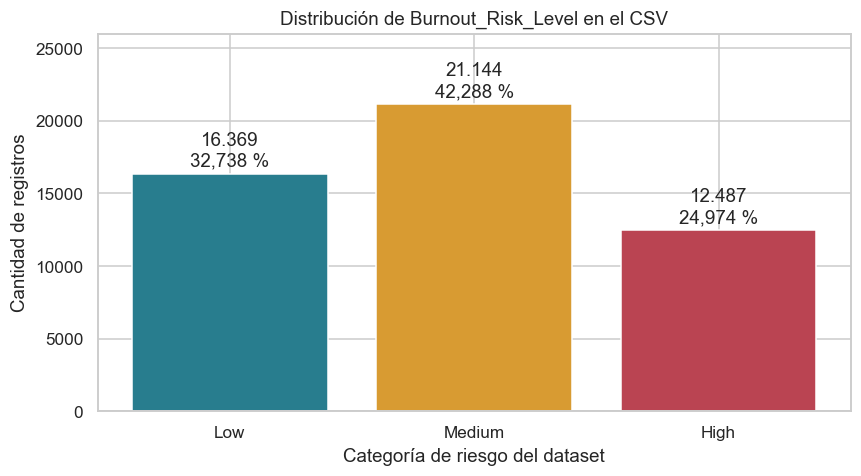

**KPI recalculado:** 12.487 / 50.000 × 100 = **24,974 %** (24,97 % a dos decimales). Coincide con la Fase 1 y docs. La clase más frecuente es `Medium` y la razón mayor/menor es 1,69. Hay desequilibrio de clases; una evaluación futura debe incluir macro F1, matriz de confusión y precision, recall y F1 por clase, con atención a High. El KPI mide composición del dataset, no desempeño predictivo, prevalencia clínica ni una mejora institucional.

In [8]:
conteos = df.Burnout_Risk_Level.value_counts().reindex(CLASES, fill_value=0)
distribucion = pd.DataFrame({'Cantidad': conteos, 'Porcentaje de todas las filas': 100 * conteos / len(df)})
tabla(distribucion)
if int(objetivo_ausente.sum() + objetivo_inesperado.sum()):
    print('Filas fuera de las tres clases:', int(objetivo_ausente.sum() + objetivo_inesperado.sum()))
n_high = int(df.Burnout_Risk_Level.eq('High').sum())
kpi = Decimal(n_high) * Decimal(100) / Decimal(len(df))
referencia_kpi = {'Total': 50_000, 'High': 12_487, 'KPI (%)': Decimal('24.974')}
contraste_kpi = pd.DataFrame([
    {'Medida': 'Total', 'Documentado': 50_000, 'Recalculado': len(df), 'Diferencia': len(df) - 50_000},
    {'Medida': 'High', 'Documentado': 12_487, 'Recalculado': n_high, 'Diferencia': n_high - 12_487},
    {'Medida': 'KPI (%)', 'Documentado': float(referencia_kpi['KPI (%)']), 'Recalculado': float(kpi),
     'Diferencia': float(kpi - referencia_kpi['KPI (%)'])},
]).set_index('Medida')
tabla(contraste_kpi)
fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.bar(CLASES, distribucion['Cantidad'], color=[PALETA[c] for c in CLASES])
ax.set(title='Distribución de Burnout_Risk_Level en el CSV', xlabel='Categoría de riesgo del dataset',
       ylabel='Cantidad de registros', ylim=(0, conteos.max() * 1.23))
for barra, clase in zip(barras, CLASES):
    ax.text(barra.get_x() + barra.get_width()/2, barra.get_height() + conteos.max()*.025,
            f'{es(conteos[clase], 0)}\n{es(distribucion.loc[clase, "Porcentaje de todas las filas"], 3)} %', ha='center')
fig.tight_layout()
plt.show()
coincide_kpi = len(df) == 50_000 and n_high == 12_487 and kpi == Decimal('24.974')
texto(f'**KPI recalculado:** {es(n_high, 0)} / {es(len(df), 0)} × 100 = **{es(kpi, 3)} %** '
      f'({es(kpi.quantize(Decimal("0.01"), rounding=ROUND_HALF_UP), 2)} % a dos decimales). '
      + ('Coincide con la Fase 1 y docs.' if coincide_kpi else 'No coincide con la referencia; prevalece el cálculo del CSV actual.') +
      f' La clase más frecuente es `{conteos.idxmax()}` y la razón mayor/menor es {es(conteos.max()/conteos.min())}. '
      'Hay desequilibrio de clases; una evaluación futura debe incluir macro F1, matriz de confusión y precision, recall y F1 por clase, '
      'con atención a High. El KPI mide composición del dataset, no desempeño predictivo, prevalencia clínica ni una mejora institucional.')


## 5. Distribuciones de las variables principales

Se combinan gráficos en paneles para evitar repetir el mismo análisis. Las medidas de la sección 2
aportan tendencia central y dispersión; los histogramas muestran forma y concentración.
Las puntuaciones ordinales se presentan como frecuencias, sin suponer una distribución continua.


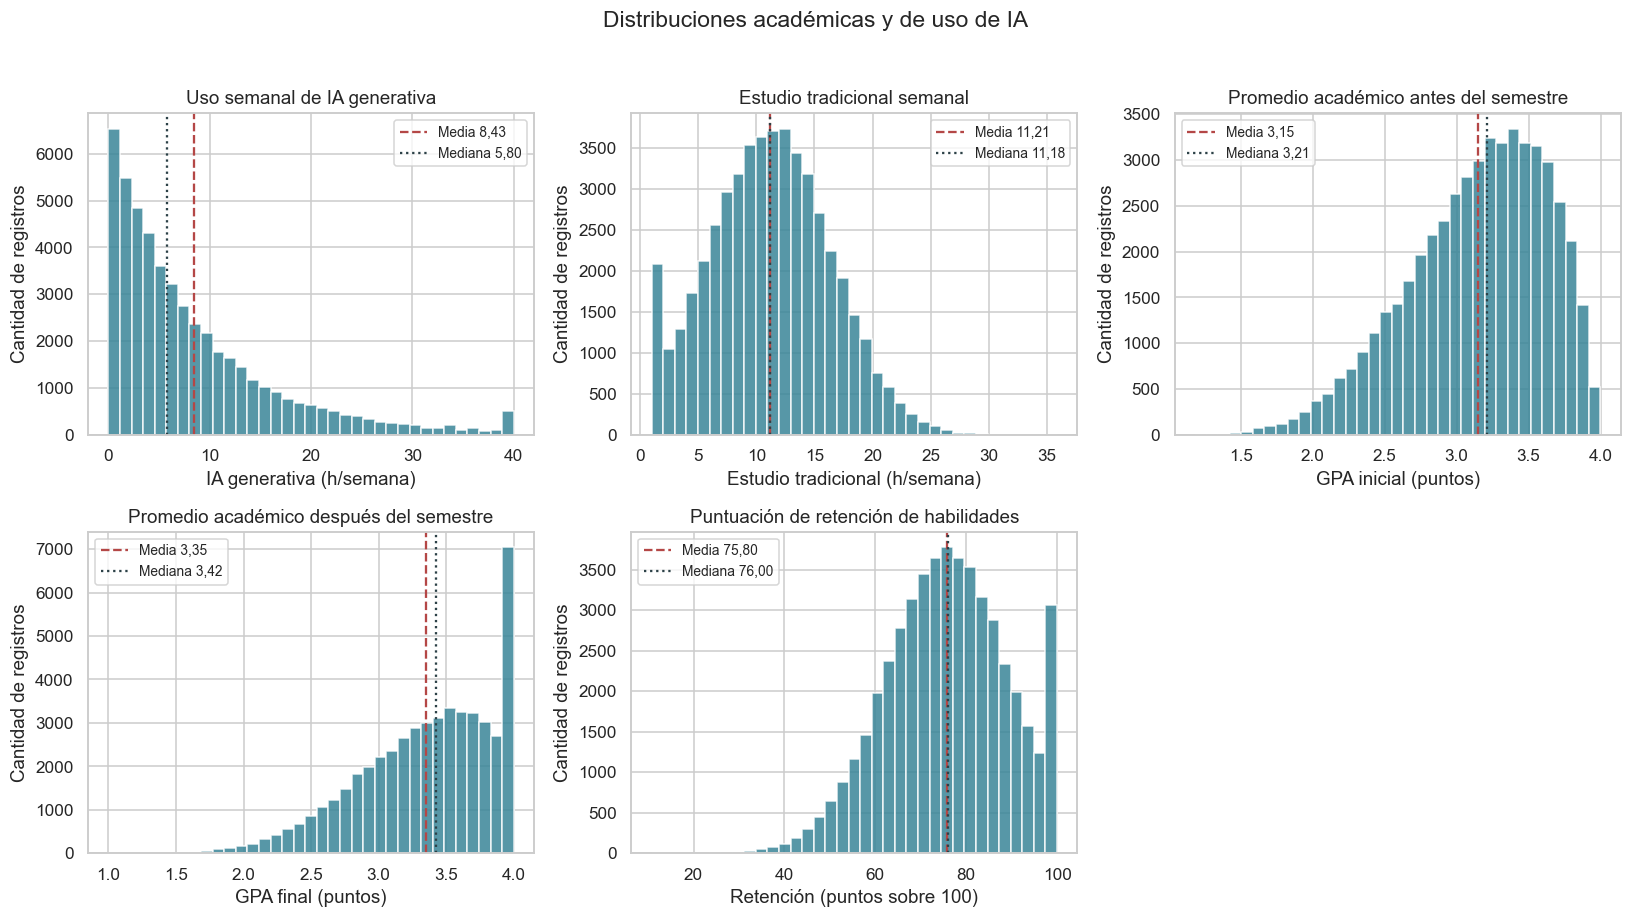

**Horas de IA:** la media (8,43) supera la mediana (5,80); la cola derecha hace conveniente usar mediana e IQR además de media y DE. El máximo observado es 40 h/semana; un máximo repetido podría reflejar un límite de generación, pero no se confirma sin documentación original.

**Estudio tradicional:** media 11,21 y DE 5,16 h/semana, con mediana 11,18. La dispersión indica hábitos heterogéneos dentro del archivo; no valida sus mediciones.

**GPA inicial y final:** medias 3,146 y 3,349 puntos. Hay 4.804 registros en el máximo final de 4; la concentración en el límite exige cautela con supuestos de normalidad. La diferencia de medias no se atribuye al uso de IA.

**Retención:** media 75,80, mediana 76,00 y DE 13,28 puntos sobre 100. La distribución incluye una cola de puntuaciones bajas que se revisa mediante IQR; no equivale por sí sola a un error.

In [9]:
continuas = ['Weekly_GenAI_Hours', 'Traditional_Study_Hours', 'Pre_Semester_GPA',
             'Post_Semester_GPA', 'Skill_Retention_Score']
fig, ejes = plt.subplots(2, 3, figsize=(15, 8.5))
for ax, c in zip(ejes.flat, continuas):
    ax.hist(df[c].dropna(), bins=35, color='#398598', alpha=.85)
    ax.axvline(df[c].mean(), color='#B44746', linestyle='--', label=f'Media {es(df[c].mean())}')
    ax.axvline(df[c].median(), color='#2C4147', linestyle=':', label=f'Mediana {es(df[c].median())}')
    ax.set(title=meta[c][0], xlabel=meta[c][1], ylabel='Cantidad de registros')
    ax.legend(fontsize=9)
ejes.flat[-1].axis('off')
fig.suptitle('Distribuciones académicas y de uso de IA', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, .96))
plt.show()
texto(f'**Horas de IA:** la media ({es(df.Weekly_GenAI_Hours.mean())}) supera la mediana '
      f'({es(df.Weekly_GenAI_Hours.median())}); la cola derecha hace conveniente usar mediana e IQR además de media y DE. '
      f'El máximo observado es {es(df.Weekly_GenAI_Hours.max(), 0)} h/semana; un máximo repetido podría reflejar un límite de generación, '
      'pero no se confirma sin documentación original.')
texto(f'**Estudio tradicional:** media {es(df.Traditional_Study_Hours.mean())} y DE '
      f'{es(df.Traditional_Study_Hours.std())} h/semana, con mediana {es(df.Traditional_Study_Hours.median())}. '
      'La dispersión indica hábitos heterogéneos dentro del archivo; no valida sus mediciones.')
texto(f'**GPA inicial y final:** medias {es(df.Pre_Semester_GPA.mean(), 3)} y '
      f'{es(df.Post_Semester_GPA.mean(), 3)} puntos. Hay {es(df.Post_Semester_GPA.eq(4).sum(), 0)} '
      'registros en el máximo final de 4; la concentración en el límite exige cautela con supuestos de normalidad. '
      'La diferencia de medias no se atribuye al uso de IA.')
texto(f'**Retención:** media {es(df.Skill_Retention_Score.mean())}, mediana {es(df.Skill_Retention_Score.median())} '
      f'y DE {es(df.Skill_Retention_Score.std())} puntos sobre 100. La distribución incluye '
      'una cola de puntuaciones bajas que se revisa mediante IQR; no equivale por sí sola a un error.')


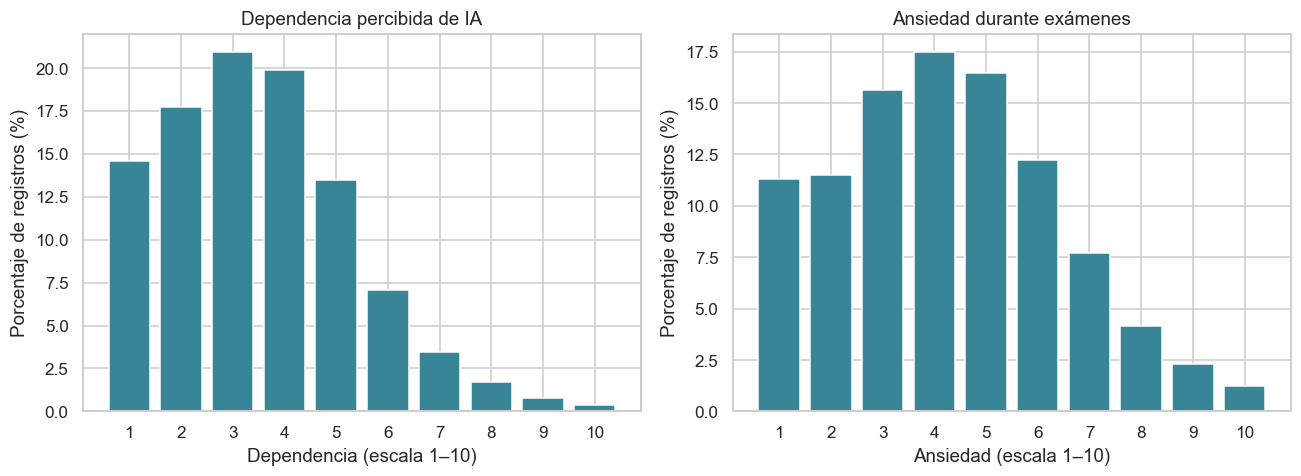

,count,median,mean,std,min,max,Q1,Q3
Perceived_AI_Dependency,"50.000,000","3,000","3,505","1,821","1,000","10,000","2,000","5,000"
Anxiety_Level_During_Exams,"50.000,000","4,000","4,271","2,144","1,000","10,000","3,000","6,000"


**Dependencia percibida de IA:** mediana 3, Q1–Q3 2–5 y media auxiliar 3,51. Las barras muestran frecuencias por nivel ordinal; la media de puntuaciones es descriptiva y no demuestra intervalos psicológicos iguales ni diagnóstico.

**Ansiedad durante exámenes:** mediana 4, Q1–Q3 3–6 y media auxiliar 4,27. Las barras muestran frecuencias por nivel ordinal; la media de puntuaciones es descriptiva y no demuestra intervalos psicológicos iguales ni diagnóstico.

In [10]:
ordinales = ['Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, c in zip(ejes, ordinales):
    frecuencias = df[c].value_counts().reindex(range(1, 11), fill_value=0)
    ax.bar(frecuencias.index, 100 * frecuencias / len(df), color='#398598')
    ax.set(title=meta[c][0], xlabel=meta[c][1], ylabel='Porcentaje de registros (%)', xticks=range(1, 11))
fig.tight_layout()
plt.show()
resumen_ordinal = df[ordinales].agg(['count', 'median', 'mean', 'std', 'min', 'max']).T
resumen_ordinal['Q1'] = df[ordinales].quantile(.25)
resumen_ordinal['Q3'] = df[ordinales].quantile(.75)
tabla(resumen_ordinal)
for c in ordinales:
    texto(f'**{meta[c][0]}:** mediana {es(df[c].median(), 0)}, Q1–Q3 '
          f'{es(df[c].quantile(.25), 0)}–{es(df[c].quantile(.75), 0)} y media auxiliar '
          f'{es(df[c].mean())}. Las barras muestran frecuencias por nivel ordinal; '
          'la media de puntuaciones es descriptiva y no demuestra intervalos psicológicos iguales ni diagnóstico.')


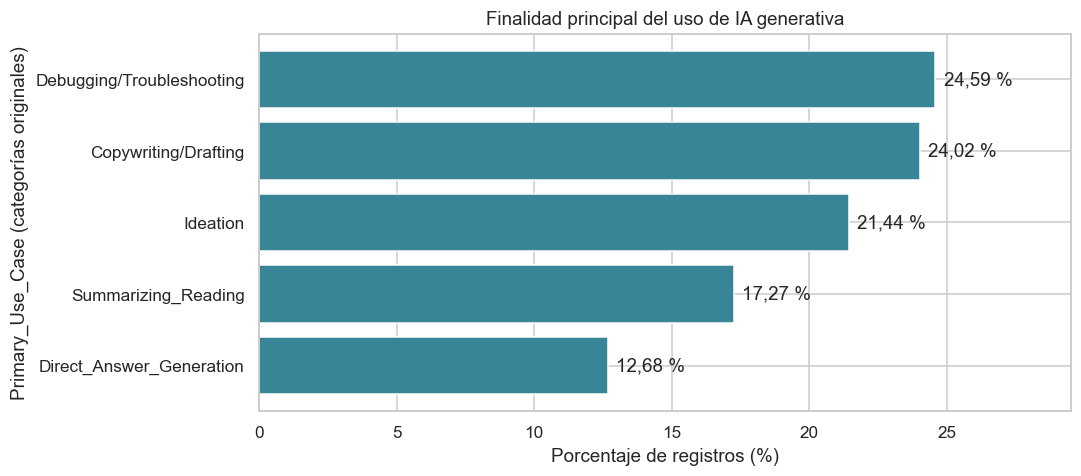

**Interpretación:** `Debugging/Troubleshooting` es la finalidad más frecuente (24,59 %); `Direct_Answer_Generation` es la menos frecuente (12,68 %). Es una variable nominal: no hay una distancia numérica válida entre finalidades. Su relación con riesgo se analiza mediante tablas cruzadas.

In [11]:
uso = df.Primary_Use_Case.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(10, 4.5))
barras = ax.barh(uso.index, 100 * uso / len(df), color='#398598')
ax.set(title='Finalidad principal del uso de IA generativa', xlabel='Porcentaje de registros (%)',
       ylabel='Primary_Use_Case (categorías originales)', xlim=(0, float(100 * uso.max()/len(df))*1.2))
for barra, n in zip(barras, uso):
    ax.text(barra.get_width()+.3, barra.get_y()+barra.get_height()/2, es(100*n/len(df))+' %', va='center')
fig.tight_layout()
plt.show()
texto(f'**Interpretación:** `{uso.idxmax()}` es la finalidad más frecuente '
      f'({es(100*uso.max()/len(df))} %); `{uso.idxmin()}` es la menos frecuente '
      f'({es(100*uso.min()/len(df))} %). Es una variable nominal: '
      'no hay una distancia numérica válida entre finalidades. Su relación con riesgo se analiza mediante tablas cruzadas.')


## 6. Posibles outliers: método IQR y revisión de plausibilidad

Se emplean cuartiles de pandas con interpolación **lineal**. Para cada variable numérica
sustantiva, `IQR = Q3 − Q1`; se marca un valor si es estrictamente menor que `Q1 − 1,5 × IQR`
o mayor que `Q3 + 1,5 × IQR`. Se excluye `Student_ID`. Las escalas discretas pueden tener
límites poco informativos: el método no reemplaza el significado de la variable.

Las cantidades por variable pueden corresponder a los mismos registros. No se suman como si
fueran estudiantes distintos. Los puntos marcados se conservan; IQR no demuestra un error.


,Q1,Q3,IQR,Límite inferior,Límite superior,Inferiores,Superiores,Total marcado,% marcado,Fuera de rango entre marcados
Pre_Semester_GPA,"2,8340","3,5210","0,6870","1,8035","4,5515",328,0,328,"0,6560",0
Weekly_GenAI_Hours,"2,3900","11,7200","9,3300","-11,6050","25,7150",0,2.583,2.583,"5,1660",0
Tool_Diversity,"2,0000","4,0000","2,0000","-1,0000","7,0000",0,0,0,"0,0000",0
Traditional_Study_Hours,"7,5600","14,7100","7,1500","-3,1650","25,4350",0,161,161,"0,3220",0
Perceived_AI_Dependency,"2,0000","5,0000","3,0000","-2,5000","9,5000",0,190,190,"0,3800",0
Anxiety_Level_During_Exams,"3,0000","6,0000","3,0000","-1,5000","10,5000",0,0,0,"0,0000",0
Post_Semester_GPA,"3,0238","3,7490","0,7252","1,9359","4,8369",346,0,346,"0,6920",0
Skill_Retention_Score,"66,8200","85,1900","18,3700","39,2650","112,7450",216,0,216,"0,4320",0


Registros distintos marcados en al menos una variable: 3269


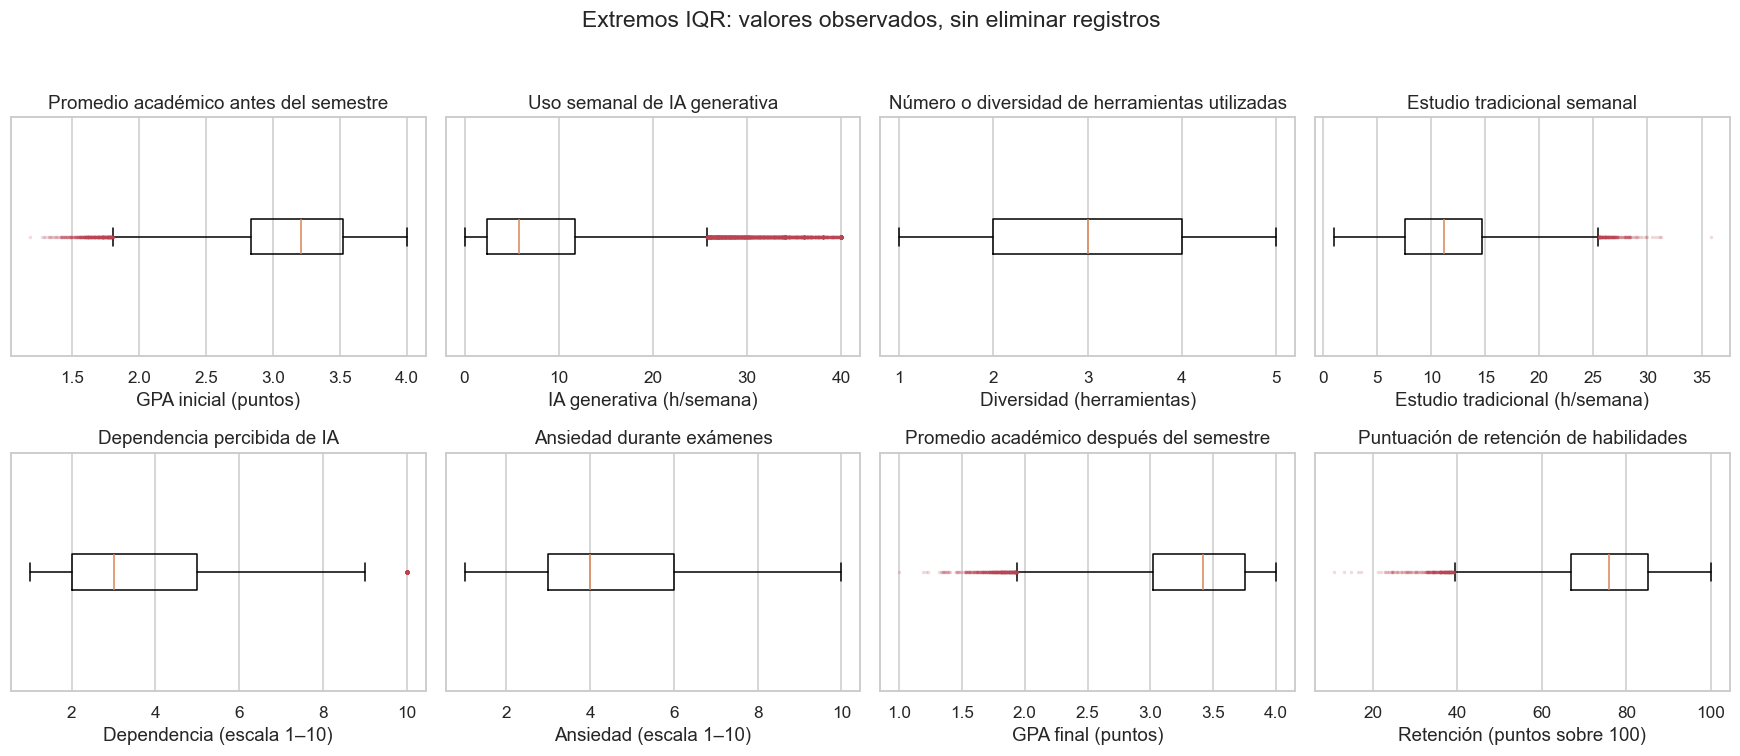

,Variable,Student_ID,Valor observado,Fuera de criterio plausible
0,Pre_Semester_GPA,110.885,"1,183",False
1,Pre_Semester_GPA,110.218,"1,803",False
2,Weekly_GenAI_Hours,127.418,"25,720",False
3,Weekly_GenAI_Hours,100.657,"40,000",False
4,Traditional_Study_Hours,121.261,"25,450",False
5,Traditional_Study_Hours,120.111,"35,860",False
6,Perceived_AI_Dependency,100.125,"10,000",False
7,Perceived_AI_Dependency,149.851,"10,000",False
8,Post_Semester_GPA,118.079,"1,000",False
9,Post_Semester_GPA,139.413,"1,935",False


**Interpretación:** los boxplots corroboran las colas detectadas por IQR. Las horas altas de IA y de estudio pueden ser comportamientos plausibles e informativos; requieren revisar periodo, unidades y posibles límites de simulación. Dependencia 10 está dentro de la escala declarada aunque IQR pueda marcarla. GPA y retención bajos caben en las escalas provisionales; requieren revisar su procedencia e instrumento, no eliminación automática. Los límites IQR negativos para horas o superiores al máximo de una escala son cercas estadísticas, no rangos válidos del dominio.

**Contraste README:** el README local no publica conteos de outliers. Ese contraste no está disponible en esta copia; no se importan cifras del remoto ni se inventan referencias. La tabla anterior constituye el cálculo reproducible para Fase 3.

In [12]:
q1 = df[numericas].quantile(.25, interpolation='linear')
q3 = df[numericas].quantile(.75, interpolation='linear')
iqr = q3 - q1
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr
mascara_inferiores = df[numericas].lt(limite_inferior)
mascara_superiores = df[numericas].gt(limite_superior)
mascara_iqr = mascara_inferiores | mascara_superiores
atipicos = pd.DataFrame({'Q1': q1, 'Q3': q3, 'IQR': iqr, 'Límite inferior': limite_inferior,
                        'Límite superior': limite_superior, 'Inferiores': mascara_inferiores.sum(),
                        'Superiores': mascara_superiores.sum(), 'Total marcado': mascara_iqr.sum(),
                        '% marcado': 100 * mascara_iqr.mean(),
                        'Fuera de rango entre marcados': [int((mascara_iqr[c] & mascaras_rango[c]).sum()) for c in numericas]})
tabla(atipicos, 4)
print('Registros distintos marcados en al menos una variable:', int(mascara_iqr.any(axis=1).sum()))
fig, ejes = plt.subplots(2, 4, figsize=(16, 7))
for ax, c in zip(ejes.flat, numericas):
    ax.boxplot(df[c].dropna(), vert=False, whis=1.5,
               flierprops={'marker': '.', 'markersize': 2.5, 'alpha': .2, 'markeredgecolor': '#BA4452'})
    ax.set(title=meta[c][0], xlabel=meta[c][1], yticks=[])
fig.suptitle('Extremos IQR: valores observados, sin eliminar registros', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, .95))
plt.show()
ejemplos_extremos = []
for c in numericas:
    if mascara_iqr[c].any():
        seleccion = df.loc[mascara_iqr[c], ['Student_ID', c]].sort_values(c)
        for indice in [seleccion.index[0], seleccion.index[-1]]:
            ejemplos_extremos.append({'Variable': c, 'Student_ID': df.at[indice, 'Student_ID'],
                                      'Valor observado': df.at[indice, c],
                                      'Fuera de criterio plausible': bool(mascaras_rango[c].loc[indice])})
tabla(pd.DataFrame(ejemplos_extremos))
texto('**Interpretación:** los boxplots corroboran las colas detectadas por IQR. '
      'Las horas altas de IA y de estudio pueden ser comportamientos plausibles e informativos; '
      'requieren revisar periodo, unidades y posibles límites de simulación. Dependencia 10 está '
      'dentro de la escala declarada aunque IQR pueda marcarla. GPA y retención bajos caben en las escalas provisionales; '
      'requieren revisar su procedencia e instrumento, no eliminación automática. '
      'Los límites IQR negativos para horas o superiores al máximo de una escala son cercas estadísticas, no rangos válidos del dominio.')
if re.search(r'outlier|at[ií]pic|\bIQR\b', readme, flags=re.I):
    texto('**Contraste README:** el texto local contiene referencias a extremos; revisar sus cifras y método antes de declararlos comparables.')
else:
    texto('**Contraste README:** el README local no publica conteos de outliers. '
          'Ese contraste no está disponible en esta copia; no se importan cifras del remoto ni se inventan referencias. '
          'La tabla anterior constituye el cálculo reproducible para Fase 3.')


## 7. Relaciones relevantes y elección de correlaciones

Para dependencia y ansiedad se usa **Spearman**, adecuado para puntuaciones ordinales y
asociaciones monotónicas. En pares continuos se muestran **Pearson** (asociación lineal) y
Spearman como complemento. Pearson de los pares con escalas ordinales se calcula únicamente
para contrastar las correlaciones publicadas en docs §17; su interpretación requiere asumir
intervalos equivalentes entre puntuaciones, lo que no está validado.

No se asignan números a Low/Medium/High para correlacionar el objetivo, ni se correlaciona
el identificador. Cada coeficiente usa pares no nulos; se muestra su tamaño efectivo.


,Variable A,Variable B,n pares,Método principal,Pearson (r),Spearman (rho)
0,Weekly_GenAI_Hours,Perceived_AI_Dependency,50.000,Spearman,"0,665479","0,555155"
1,Perceived_AI_Dependency,Anxiety_Level_During_Exams,50.000,Spearman,"0,307620","0,280295"
2,Weekly_GenAI_Hours,Anxiety_Level_During_Exams,50.000,Spearman,"0,269080","0,221188"
3,Pre_Semester_GPA,Post_Semester_GPA,50.000,Pearson + Spearman,"0,926781","0,917233"
4,Weekly_GenAI_Hours,Skill_Retention_Score,50.000,Pearson + Spearman,"-0,118099","-0,038910"


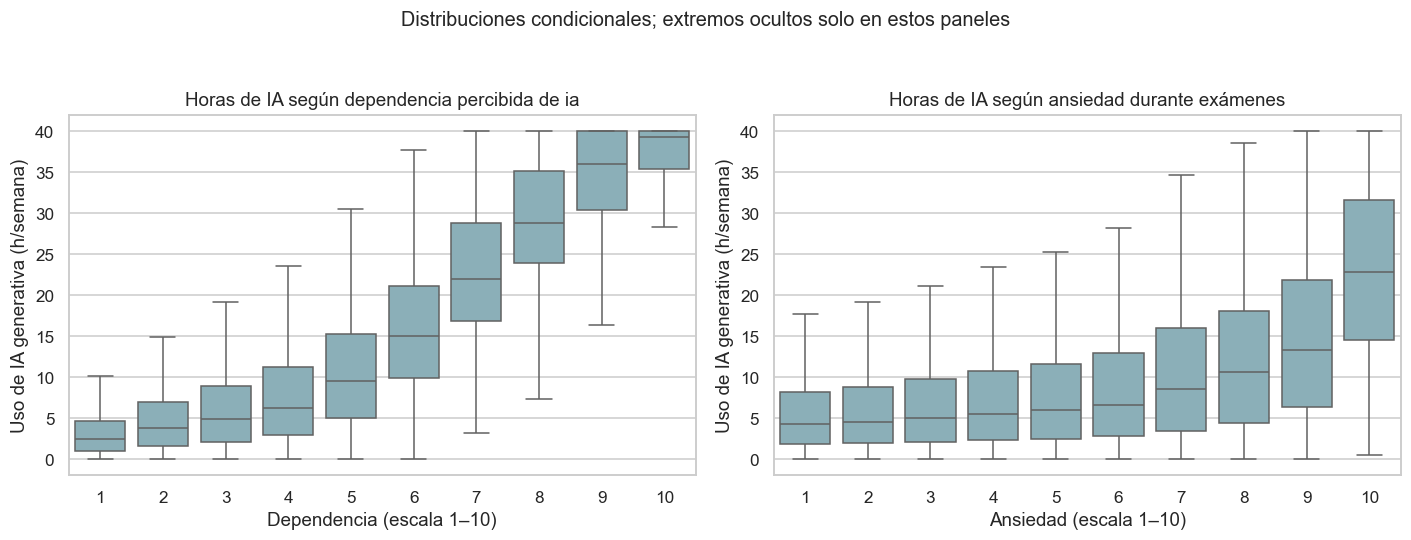

**Uso semanal de IA generativa y dependencia percibida de ia:** Spearman = 0,555. Se observa una asociación positiva en el archivo; los boxplots muestran dispersión dentro de cada nivel. Ocultar los puntos extremos facilita la lectura y no cambia datos ni correlaciones. La asociación no permite atribuir ansiedad o dependencia al uso de IA ni identificar individualmente una etiqueta de riesgo.

**Uso semanal de IA generativa y ansiedad durante exámenes:** Spearman = 0,221. Se observa una asociación positiva en el archivo; los boxplots muestran dispersión dentro de cada nivel. Ocultar los puntos extremos facilita la lectura y no cambia datos ni correlaciones. La asociación no permite atribuir ansiedad o dependencia al uso de IA ni identificar individualmente una etiqueta de riesgo.

In [13]:
pares = [
    ('Weekly_GenAI_Hours', 'Perceived_AI_Dependency', 'Spearman'),
    ('Perceived_AI_Dependency', 'Anxiety_Level_During_Exams', 'Spearman'),
    ('Weekly_GenAI_Hours', 'Anxiety_Level_During_Exams', 'Spearman'),
    ('Pre_Semester_GPA', 'Post_Semester_GPA', 'Pearson + Spearman'),
    ('Weekly_GenAI_Hours', 'Skill_Retention_Score', 'Pearson + Spearman'),
]
relaciones = pd.DataFrame([
    {'Variable A': a, 'Variable B': b, 'n pares': len(df[[a, b]].dropna()),
     'Método principal': metodo, 'Pearson (r)': df[a].corr(df[b], method='pearson'),
     'Spearman (rho)': df[a].corr(df[b], method='spearman')}
    for a, b, metodo in pares
])
tabla(relaciones, 6)

fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for ax, c in zip(ejes, ['Perceived_AI_Dependency', 'Anxiety_Level_During_Exams']):
    sns.boxplot(data=df, x=c, y='Weekly_GenAI_Hours', order=list(range(1, 11)),
                color='#83B4C0', showfliers=False, ax=ax)
    ax.set(title=f'Horas de IA según {meta[c][0].lower()}', xlabel=meta[c][1],
           ylabel='Uso de IA generativa (h/semana)')
fig.suptitle('Distribuciones condicionales; extremos ocultos solo en estos paneles', fontsize=13)
fig.tight_layout(rect=(0, 0, 1, .94))
plt.show()
for a, b, _ in pares[:3:2]:
    rho = df[a].corr(df[b], method='spearman')
    texto(f'**{meta[a][0]} y {meta[b][0].lower()}:** Spearman = {es(rho, 3)}. '
          'Se observa una asociación positiva en el archivo; los boxplots muestran dispersión dentro de cada nivel. '
          'Ocultar los puntos extremos facilita la lectura y no cambia datos ni correlaciones. '
          'La asociación no permite atribuir ansiedad o dependencia al uso de IA ni identificar individualmente una etiqueta de riesgo.')


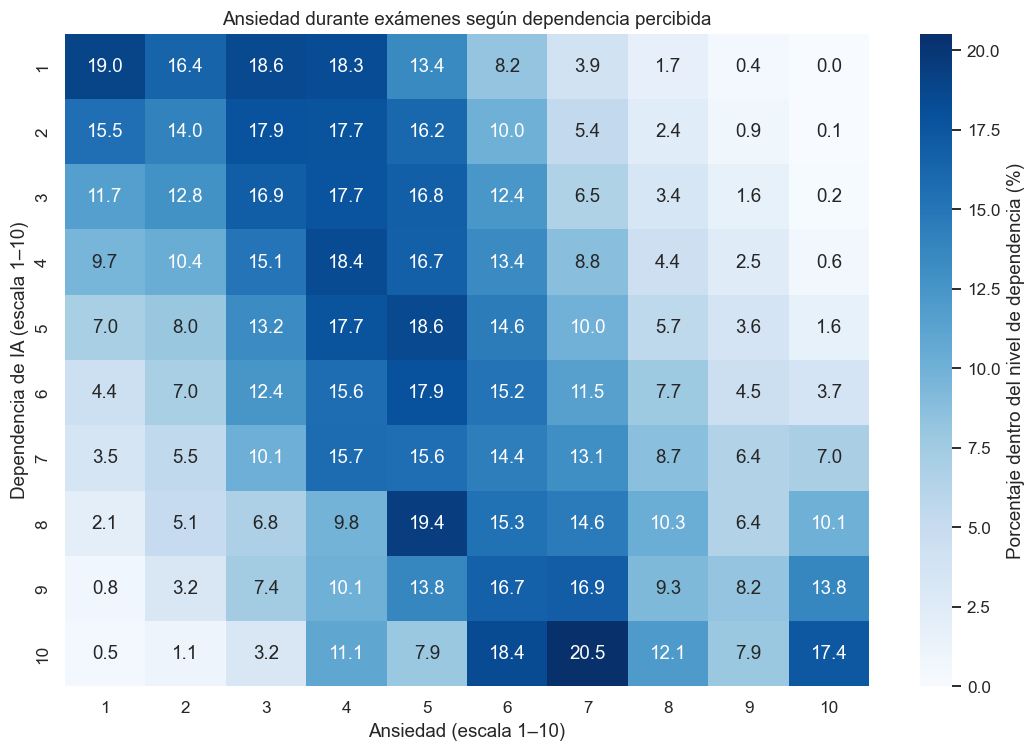

,n por nivel de dependencia
Perceived_AI_Dependency,
1,7.303
2,8.874
3,10.478
4,9.934
5,6.745
6,3.521
7,1.722
8,855
9,378


**Interpretación:** dependencia y ansiedad tienen Spearman 0,280. El mapa muestra distribuciones de ansiedad dentro de cada nivel de dependencia, con denominadores distintos indicados en la tabla. La relación es positiva, con considerable variación; no demuestra causalidad ni una equivalencia entre ansiedad y burnout.

In [14]:
dependencia_ansiedad = pd.crosstab(df.Perceived_AI_Dependency, df.Anxiety_Level_During_Exams)
dependencia_ansiedad = dependencia_ansiedad.reindex(index=range(1, 11), columns=range(1, 11), fill_value=0)
porcentaje_ansiedad = 100 * dependencia_ansiedad.div(dependencia_ansiedad.sum(axis=1).replace(0, np.nan), axis=0)
fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(porcentaje_ansiedad, cmap='Blues', annot=True, fmt='.1f', ax=ax,
            cbar_kws={'label': 'Porcentaje dentro del nivel de dependencia (%)'})
ax.set(title='Ansiedad durante exámenes según dependencia percibida',
       xlabel='Ansiedad (escala 1–10)', ylabel='Dependencia de IA (escala 1–10)')
fig.tight_layout()
plt.show()
tabla(pd.DataFrame({'n por nivel de dependencia': dependencia_ansiedad.sum(axis=1)}), 0)
texto(f'**Interpretación:** dependencia y ansiedad tienen Spearman '
      f'{es(df.Perceived_AI_Dependency.corr(df.Anxiety_Level_During_Exams, method="spearman"), 3)}. '
      'El mapa muestra distribuciones de ansiedad dentro de cada nivel de dependencia, con denominadores distintos '
      'indicados en la tabla. La relación es positiva, con considerable variación; no demuestra causalidad '
      'ni una equivalencia entre ansiedad y burnout.')


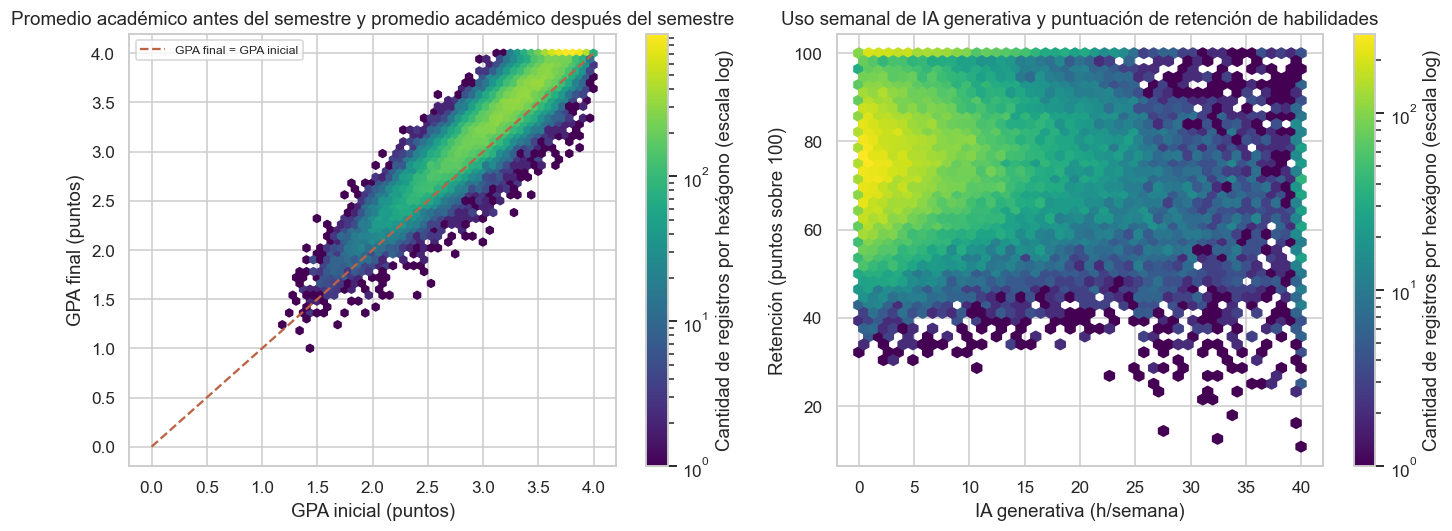

,"Cambio de GPA (cálculo exploratorio, puntos)"
count,"50.000,000"
mean,"0,203"
std,"0,187"
min,"-0,924"
25%,"0,087"
50%,"0,204"
75%,"0,325"
max,"1,008"


**GPA anterior y posterior:** Pearson 0,927 y Spearman 0,917 muestran una asociación positiva fuerte. El cambio medio es 0,203 puntos. Se calcula una serie auxiliar sin añadir columnas al dataset; pre/post no equivale a un diseño causal o una intervención.

**Horas de IA y retención:** Pearson -0,118 y Spearman -0,039. La asociación lineal negativa es débil y la monotónica es aún menor; la nube muestra amplia dispersión. Los coeficientes distintos advierten que forma de distribución y extremos pueden influir en la descripción. No se concluye que usar IA reduzca habilidades.

In [15]:
fig, ejes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (a, b) in zip(ejes, [(pares[3][0], pares[3][1]), (pares[4][0], pares[4][1])]):
    hexbins = ax.hexbin(df[a], df[b], gridsize=45, mincnt=1, bins='log', cmap='viridis')
    fig.colorbar(hexbins, ax=ax, label='Cantidad de registros por hexágono (escala log)')
    ax.set(title=f'{meta[a][0]} y {meta[b][0].lower()}', xlabel=meta[a][1], ylabel=meta[b][1])
    if a == 'Pre_Semester_GPA':
        ax.plot([0, 4], [0, 4], linestyle='--', color='#BD6344', label='GPA final = GPA inicial')
        ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
gpa_cambio = df.Post_Semester_GPA - df.Pre_Semester_GPA
tabla(gpa_cambio.describe().to_frame('Cambio de GPA (cálculo exploratorio, puntos)'))
texto(f'**GPA anterior y posterior:** Pearson {es(df.Pre_Semester_GPA.corr(df.Post_Semester_GPA), 3)} y '
      f'Spearman {es(df.Pre_Semester_GPA.corr(df.Post_Semester_GPA, method="spearman"), 3)} muestran una asociación positiva fuerte. '
      f'El cambio medio es {es(gpa_cambio.mean(), 3)} puntos. '
      'Se calcula una serie auxiliar sin añadir columnas al dataset; pre/post no equivale a un diseño causal o una intervención.')
texto(f'**Horas de IA y retención:** Pearson {es(df.Weekly_GenAI_Hours.corr(df.Skill_Retention_Score), 3)} y '
      f'Spearman {es(df.Weekly_GenAI_Hours.corr(df.Skill_Retention_Score, method="spearman"), 3)}. '
      'La asociación lineal negativa es débil y la monotónica es aún menor; la nube muestra amplia dispersión. '
      'Los coeficientes distintos advierten que forma de distribución y extremos pueden influir en la descripción. '
      'No se concluye que usar IA reduzca habilidades.')


## 8. Comparación de Low, Medium y High

Se muestran tamaños, medias, medianas, DE y cuartiles. Las medias de puntuaciones ordinales
se incluyen para reproducir docs; mediana y distribución son referencias principales para esas escalas.
El objetivo se analiza como agrupación categórica y no como puntuación numérica.


,n registros
Burnout_Risk_Level,
Low,16.369
Medium,21.144
High,12.487


,Weekly_GenAI_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Traditional_Study_Hours,Pre_Semester_GPA,Post_Semester_GPA,Skill_Retention_Score
Riesgo: medias,,,,,,,
Low,"4,644","2,820","3,928","11,966","3,204","3,405","76,402"
Medium,"7,349","3,365","4,170","11,290","3,138","3,348","76,243"
High,"15,215","4,642","4,889","10,082","3,083","3,278","74,253"


n 
 Media 
 Mediana 
 DE 
 Q1 
 Q3 
 Mínimo 
 Máximo 
 
 
 Variable 
 Burnout_Risk_Level 
   
   
   
   
   
   
   
   
 
 
 
 
 Weekly_GenAI_Hours 
 Low 
 16.369 
 4,644 
 3,410 
 4,266 
 1,450 
 6,630 
 0,000 
 38,000 
 
 
 Medium 
 21.144 
 7,349 
 5,625 
 6,453 
 2,460 
 10,410 
 0,000 
 40,000 
 
 
 High 
 12.487 
 15,215 
 13,250 
 10,614 
 6,600 
 21,990 
 0,000 
 40,000 
 
 
 Perceived_AI_Dependency 
 Low 
 16.369 
 2,820 
 3,000 
 1,421 
 2,000 
 4,000 
 1,000 
 9,000 
 
 
 Medium 
 21.144 
 3,365 
 3,000 
 1,621 
 2,000 
 4,000 
 1,000 
 10,000 
 
 
 High 
 12.487 
 4,642 
 5,000 
 2,059 
 3,000 
 6,000 
 1,000 
 10,000 
 
 
 Anxiety_Level_During_Exams 
 Low 
 16.369 
 3,928 
 4,000 
 1,987 
 2,000 
 5,000 
 1,000 
 10,000 
 
 
 Medium 
 21.144 
 4,170 
 4,000 
 2,067 
 3,000 
 6,000 
 1,000 
 10,000 
 
 
 High 
 12.487 
 4,889 
 5,000 
 2,333 
 3,000 
 6,000 
 1,000 
 10,000 
 
 
 Traditional_Study_Hours 
 Low 
 16.369 
 11,966 
 11,970 
 5,137 
 8,380 
 15,450 
 1,000 
 35,860 
 
 
 Medium 
 21.144 
 11,290 
 11,280 
 5,113 
 7,710 
 14,770 
 1,000 
 31,130 
 
 
 High 
 12.487 
 10,082 
 9,990 
 5,059 
 6,410 
 13,520 
 1,000 
 29,750 
 
 
 Pre_Semester_GPA 
 Low 
 16.369 
 3,204 
 3,271 
 0,459 
 2,910 
 3,561 
 1,275 
 3,997 
 
 
 Medium 
 21.144 
 3,138 
 3,200 
 0,479 
 2,828 
 3,512 
 1,292 
 3,998 
 
 
 High 
 12.487 
 3,083 
 3,143 
 0,495 
 2,753 
 3,469 
 1,183 
 3,991 
 
 
 Post_Semester_GPA 
 Low 
 16.369 
 3,405 
 3,479 
 0,472 
 3,103 
 3,788 
 1,316 
 4,000 
 
 
 Medium 
 21.144 
 3,348 
 3,418 
 0,494 
 3,021 
 3,748 
 1,190 
 4,000 
 
 
 High 
 12.487 
 3,278 
 3,343 
 0,520 
 2,930 
 3,695 
 1,000 
 4,000 
 
 
 Skill_Retention_Score 
 Low 
 16.369 
 76,402 
 76,450 
 12,835 
 67,550 
 85,360 
 30,180 
 100,000 
 
 
 Medium 
 21.144 
 76,243 
 76,410 
 12,985 
 67,340 
 85,510 
 23,660 
 100,000 
 
 
 High 
 12.487 
 74,253 
 74,600 
 14,203 
 64,905 
 84,330 
 10,780 
 100,000

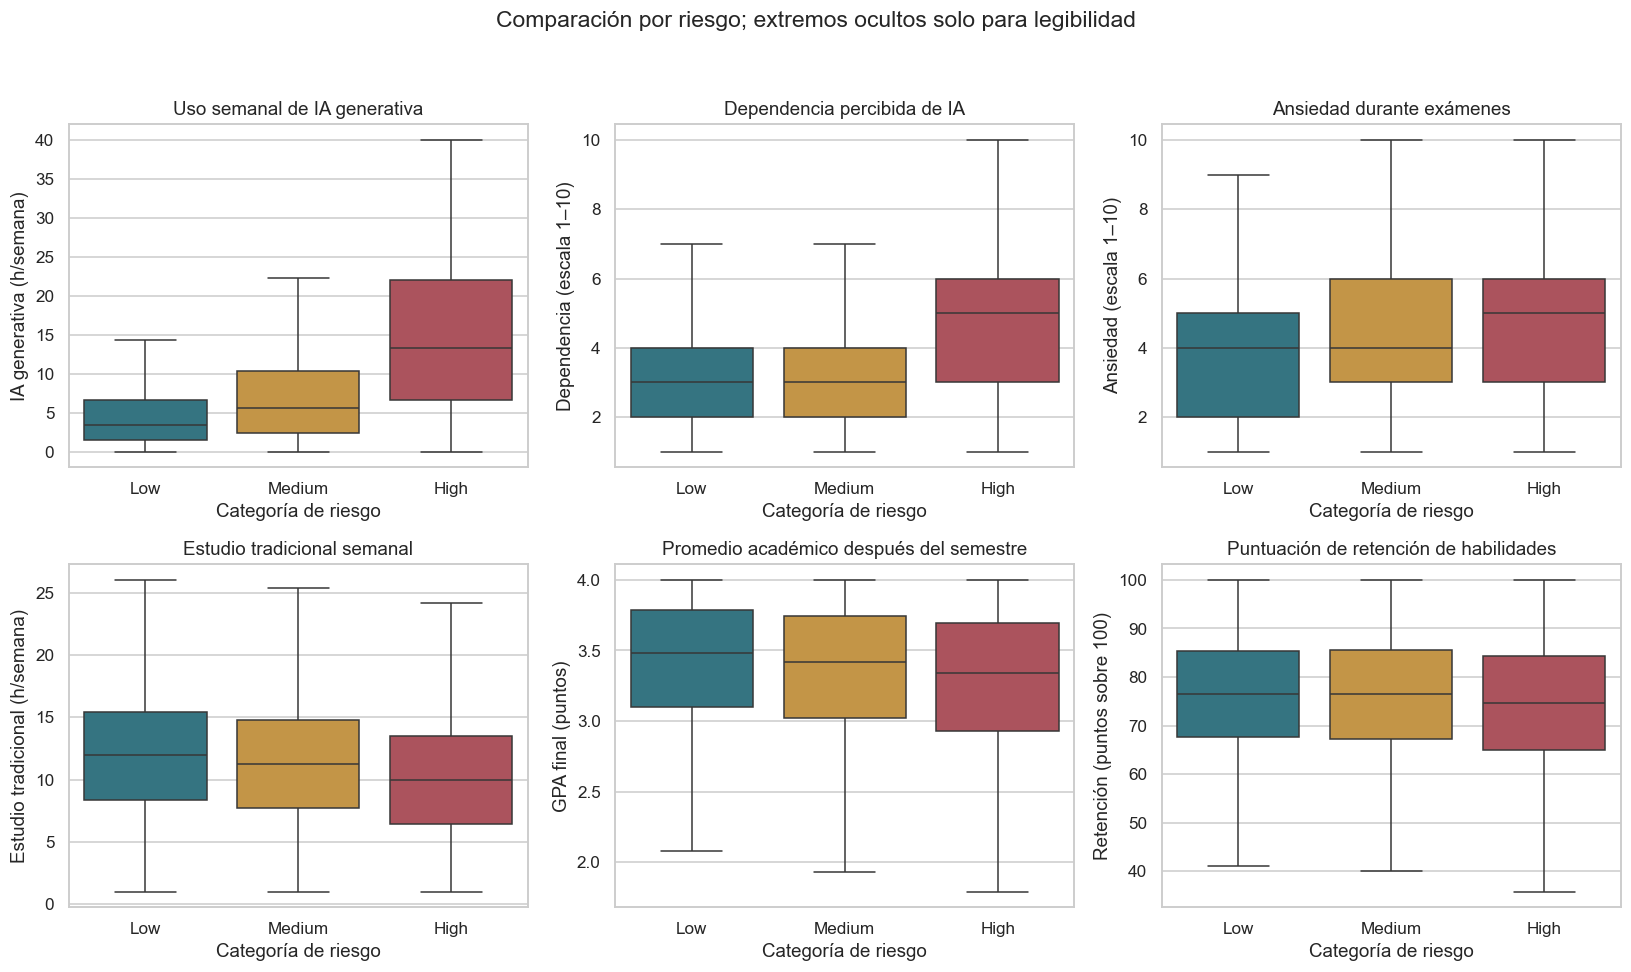

**Uso semanal de IA generativa:** medias Low / Medium / High = 4,644 / 7,349 / 15,215; medianas = 3,410 / 5,625 / 13,250. El panel y los cuartiles muestran diferencias de distribución y solapamiento; son comparaciones descriptivas sin atribución causal.

**Dependencia percibida de IA:** medias Low / Medium / High = 2,820 / 3,365 / 4,642; medianas = 3,000 / 3,000 / 5,000. El panel y los cuartiles muestran diferencias de distribución y solapamiento; son comparaciones descriptivas sin atribución causal.

**Ansiedad durante exámenes:** medias Low / Medium / High = 3,928 / 4,170 / 4,889; medianas = 4,000 / 4,000 / 5,000. El panel y los cuartiles muestran diferencias de distribución y solapamiento; son comparaciones descriptivas sin atribución causal.

**Estudio tradicional semanal:** medias Low / Medium / High = 11,966 / 11,290 / 10,082; medianas = 11,970 / 11,280 / 9,990. El panel y los cuartiles muestran diferencias de distribución y solapamiento; son comparaciones descriptivas sin atribución causal.

**Promedio académico después del semestre:** medias Low / Medium / High = 3,405 / 3,348 / 3,278; medianas = 3,479 / 3,418 / 3,343. El panel y los cuartiles muestran diferencias de distribución y solapamiento; son comparaciones descriptivas sin atribución causal.

**Puntuación de retención de habilidades:** medias Low / Medium / High = 76,402 / 76,243 / 74,253; medianas = 76,450 / 76,410 / 74,600. El panel y los cuartiles muestran diferencias de distribución y solapamiento; son comparaciones descriptivas sin atribución causal.

**GPA inicial:** media Low 3,204 frente a High 3,083. Los grupos ya difieren en el rendimiento previo; una diferencia en GPA final no puede atribuirse aisladamente al uso de IA.

In [16]:
principales = ['Weekly_GenAI_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
               'Traditional_Study_Hours', 'Pre_Semester_GPA', 'Post_Semester_GPA', 'Skill_Retention_Score']
grupos = df.groupby('Burnout_Risk_Level', observed=True)
tabla(grupos.size().reindex(CLASES).to_frame('n registros'), 0)
medias_grupo = grupos[principales].mean().reindex(CLASES)
medianas_grupo = grupos[principales].median().reindex(CLASES)
tabla(medias_grupo.rename_axis('Riesgo: medias'))
resumen_grupos = pd.concat([
    grupos[c].agg(n='count', Media='mean', Mediana='median', DE='std',
                  Q1=lambda s: s.quantile(.25), Q3=lambda s: s.quantile(.75), Mínimo='min', Máximo='max')
      .reindex(CLASES).assign(Variable=c)
    for c in principales
]).reset_index().set_index(['Variable', 'Burnout_Risk_Level'])
tabla(resumen_grupos)
fig, ejes = plt.subplots(2, 3, figsize=(15, 9))
comparar = ['Weekly_GenAI_Hours', 'Perceived_AI_Dependency', 'Anxiety_Level_During_Exams',
            'Traditional_Study_Hours', 'Post_Semester_GPA', 'Skill_Retention_Score']
for ax, c in zip(ejes.flat, comparar):
    sns.boxplot(data=df, x='Burnout_Risk_Level', y=c, hue='Burnout_Risk_Level', order=CLASES,
                hue_order=CLASES, palette=PALETA, legend=False, showfliers=False, ax=ax)
    ax.set(title=meta[c][0], xlabel='Categoría de riesgo', ylabel=meta[c][1])
fig.suptitle('Comparación por riesgo; extremos ocultos solo para legibilidad', fontsize=15)
fig.tight_layout(rect=(0, 0, 1, .95))
plt.show()
for c in comparar:
    texto(f'**{meta[c][0]}:** medias Low / Medium / High = '
          + ' / '.join(es(medias_grupo.loc[g, c], 3) for g in CLASES)
          + '; medianas = ' + ' / '.join(es(medianas_grupo.loc[g, c], 3) for g in CLASES)
          + '. El panel y los cuartiles muestran diferencias de distribución y solapamiento; '
            'son comparaciones descriptivas sin atribución causal.')
texto(f'**GPA inicial:** media Low {es(medias_grupo.loc["Low", "Pre_Semester_GPA"], 3)} frente a '
      f'High {es(medias_grupo.loc["High", "Pre_Semester_GPA"], 3)}. '
      'Los grupos ya difieren en el rendimiento previo; una diferencia en GPA final no puede atribuirse aisladamente al uso de IA.')


Burnout_Risk_Level,Low,Medium,High,Total
Primary_Use_Case,,,,
Copywriting/Drafting,4.076,5.174,2.761,12.011
Debugging/Troubleshooting,3.822,5.119,3.354,12.295
Direct_Answer_Generation,2.021,2.632,1.687,6.340
Ideation,3.542,4.568,2.611,10.721
Summarizing_Reading,2.908,3.651,2.074,8.633


Burnout_Risk_Level,Low,Medium,High
Porcentaje dentro de cada finalidad,,,
Copywriting/Drafting,"33,936","43,077","22,987"
Debugging/Troubleshooting,"31,086","41,635","27,279"
Direct_Answer_Generation,"31,877","41,514","26,609"
Ideation,"33,038","42,608","24,354"
Summarizing_Reading,"33,685","42,291","24,024"


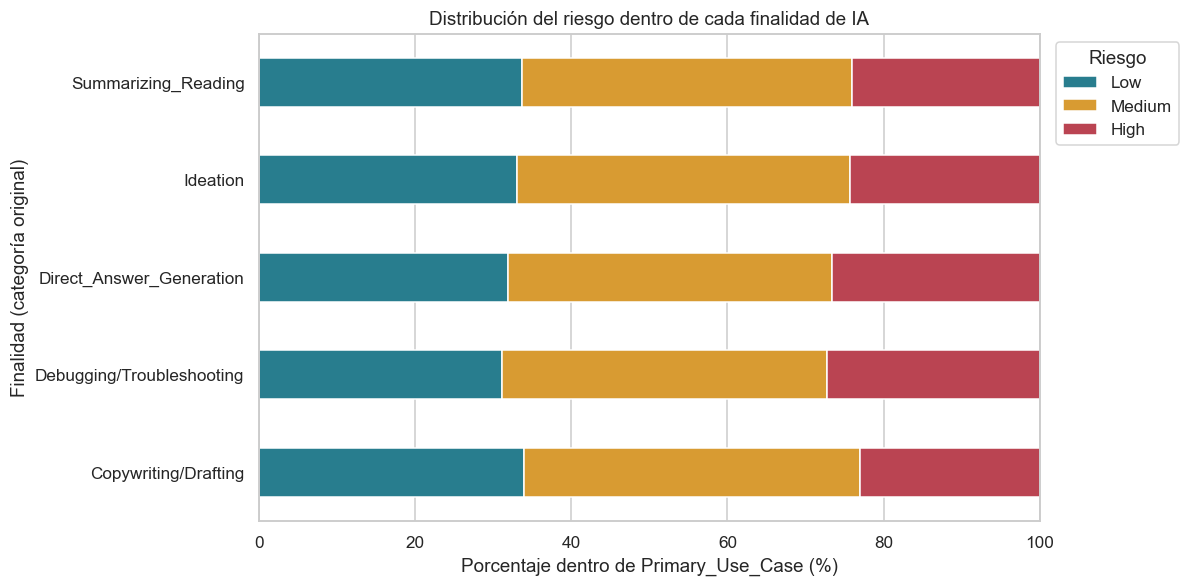

**Interpretación:** la proporción High por finalidad va de 22,99 % (`Copywriting/Drafting`) a 27,28 % (`Debugging/Troubleshooting`). La tabla distingue tamaños absolutos de composición dentro de cada finalidad. No demuestra que una finalidad produzca burnout; intensidad, contexto y generación de la etiqueta podrían influir.

In [17]:
tabla_uso_riesgo = pd.crosstab(df.Primary_Use_Case, df.Burnout_Risk_Level).reindex(columns=CLASES, fill_value=0)
porcentajes_uso_riesgo = 100 * tabla_uso_riesgo.div(tabla_uso_riesgo.sum(axis=1), axis=0)
tabla(tabla_uso_riesgo.assign(Total=tabla_uso_riesgo.sum(axis=1)), 0)
tabla(porcentajes_uso_riesgo.rename_axis('Porcentaje dentro de cada finalidad'))
fig, ax = plt.subplots(figsize=(11, 5.5))
porcentajes_uso_riesgo.plot.barh(stacked=True, color=[PALETA[c] for c in CLASES], ax=ax)
ax.set(title='Distribución del riesgo dentro de cada finalidad de IA',
       xlabel='Porcentaje dentro de Primary_Use_Case (%)', ylabel='Finalidad (categoría original)', xlim=(0, 100))
ax.legend(title='Riesgo', bbox_to_anchor=(1.01, 1), loc='upper left')
fig.tight_layout()
plt.show()
texto(f'**Interpretación:** la proporción High por finalidad va de '
      f'{es(porcentajes_uso_riesgo.High.min())} % (`{porcentajes_uso_riesgo.High.idxmin()}`) a '
      f'{es(porcentajes_uso_riesgo.High.max())} % (`{porcentajes_uso_riesgo.High.idxmax()}`). '
      'La tabla distingue tamaños absolutos de composición dentro de cada finalidad. '
      'No demuestra que una finalidad produzca burnout; intensidad, contexto y generación de la etiqueta podrían influir.')


## 9. Reproducción de resultados publicados en docs y README local

Las referencias numéricas se extraen del documento local al ejecutar estas celdas.
Se compara el valor recalculado, su diferencia y su redondeo a la precisión publicada
(`ROUND_HALF_UP`). Una coincidencia por redondeo no exige identidad a más decimales.
Una discrepancia se conserva: no se alteran datos ni resultados para hacerlos coincidir.


In [18]:
def decimal_documentado(cadena):
    return Decimal(cadena.strip().replace('%', '').replace(' ', '').replace('.', '').replace(',', '.'))
def filas_tabla_documento(numero):
    return [[v.strip() for v in linea.strip().strip('|').split('|')]
            for linea in seccion(numero).splitlines() if linea.strip().startswith('|')]
def contraste_numerico(indicador, ref, actual, precision, fuente):
    actual_decimal = Decimal(str(actual))
    redondeado = actual_decimal.quantize(Decimal(1).scaleb(-precision), rounding=ROUND_HALF_UP)
    return {'Indicador': indicador, 'Fuente': fuente, 'Documentado': float(ref),
            'Recalculado': float(actual_decimal), 'Diferencia': float(actual_decimal-ref),
            'Recalculado a precisión publicada': float(redondeado),
            'Coincide a precisión publicada': redondeado == ref}

mapa_filas = {'Horas de IA por semana': 'Weekly_GenAI_Hours',
              'Dependencia percibida de IA': 'Perceived_AI_Dependency',
              'Ansiedad durante exámenes': 'Anxiety_Level_During_Exams',
              'Horas de estudio tradicional': 'Traditional_Study_Hours',
              'GPA final': 'Post_Semester_GPA', 'Retención de habilidades': 'Skill_Retention_Score'}
contrastes_grupo = []
for fila in filas_tabla_documento(18):
    if fila[0] in mapa_filas:
        for g, valor in zip(CLASES, fila[1:4]):
            ref = decimal_documentado(valor)
            contrastes_grupo.append(contraste_numerico(f'{mapa_filas[fila[0]]} · {g}', ref,
                                      medias_grupo.loc[g, mapa_filas[fila[0]]], 2, 'docs §18'))
if len(contrastes_grupo) != 18:
    raise ValueError('La tabla de docs §18 cambió; revisar referencias antes de contrastar medias por grupo.')
contrastes_grupo = pd.DataFrame(contrastes_grupo)
tabla(contrastes_grupo, 6)

contrastes_generales = []
for c in ['Perceived_AI_Dependency', 'Traditional_Study_Hours', 'Anxiety_Level_During_Exams',
          'Skill_Retention_Score', 'Pre_Semester_GPA', 'Post_Semester_GPA']:
    bloque = re.search(rf'^### `{re.escape(c)}`.*?(?=^### |\Z)', seccion(13), flags=re.M | re.S).group(0)
    ref = decimal_documentado(re.search(r'Promedio aproximado:\s*\*\*([+\d,.]+)', bloque).group(1))
    contrastes_generales.append(contraste_numerico(f'Media global · {c}', ref, df[c].mean(), 2, 'docs §13'))
refs_correlacion = re.findall(r'Correlación aproximada:\s*\*\*([-\d,]+)', seccion(17))
pares_doc = [pares[3], pares[0], pares[1], pares[2], pares[4]]
if len(refs_correlacion) != len(pares_doc):
    raise ValueError('Cambió la estructura de correlaciones en docs §17; revisar referencias.')
for (a, b, _), ref in zip(pares_doc, refs_correlacion):
    contrastes_generales.append(contraste_numerico(f'Pearson · {a} / {b}', decimal_documentado(ref),
                                                df[a].corr(df[b]), 3, 'docs §17; Pearson explícito'))
ref_cambio = decimal_documentado(re.search(r'Promedio observado aproximado:\s*\*\*([+\d,]+)', seccion(19)).group(1))
contrastes_generales.append(contraste_numerico('Media cambio GPA', ref_cambio, gpa_cambio.mean(), 3, 'docs §19'))
for fila in filas_tabla_documento(16):
    if fila[0] in CLASES:
        g = fila[0]
        contrastes_generales.append(contraste_numerico(f'Cantidad · {g}', decimal_documentado(fila[1]), int(conteos[g]), 0, 'docs §16'))
        contrastes_generales.append(contraste_numerico(f'Porcentaje · {g}', decimal_documentado(fila[2]), 100*conteos[g]/len(df), 2, 'docs §16'))
contrastes_generales = pd.DataFrame(contrastes_generales)
tabla(contrastes_generales, 6)
discrepancias_medias = contrastes_grupo.loc[~contrastes_grupo['Coincide a precisión publicada']].copy()
tabla(discrepancias_medias, 6)
texto(f'**Interpretación:** {len(discrepancias_medias)} discrepancias actuales en las 18 medias por grupo. Las tres cifras históricas corregidas se documentan en docs §29; no se alteraron valores del CSV. Pearson reproduce las referencias históricas y Spearman sustenta las relaciones con escalas ordinales.')
assert contrastes_grupo['Coincide a precisión publicada'].all()
assert contrastes_generales['Coincide a precisión publicada'].all()


,Indicador,Fuente,Documentado,Recalculado,Diferencia,Recalculado a precisión publicada,Coincide a precisión publicada
0,Weekly_GenAI_Hours · Low,docs §18,"4,640000","4,643648","0,003648","4,640000",True
1,Weekly_GenAI_Hours · Medium,docs §18,"7,350000","7,349047","-0,000953","7,350000",True
2,Weekly_GenAI_Hours · High,docs §18,"15,210000","15,214823","0,004823","15,210000",True
3,Perceived_AI_Dependency · Low,docs §18,"2,820000","2,819965","-0,000035","2,820000",True
4,Perceived_AI_Dependency · Medium,docs §18,"3,360000","3,364879","0,004879","3,360000",True
5,Perceived_AI_Dependency · High,docs §18,"4,640000","4,641707","0,001707","4,640000",True
6,Anxiety_Level_During_Exams · Low,docs §18,"3,930000","3,928462","-0,001538","3,930000",True
7,Anxiety_Level_During_Exams · Medium,docs §18,"4,170000","4,170450","0,000450","4,170000",True
8,Anxiety_Level_During_Exams · High,docs §18,"4,890000","4,889325","-0,000675","4,890000",True
9,Traditional_Study_Hours · Low,docs §18,"11,970000","11,965504","-0,004496","11,970000",True


,Indicador,Fuente,Documentado,Recalculado,Diferencia,Recalculado a precisión publicada,Coincide a precisión publicada
0,Media global · Perceived_AI_Dependency,docs §13,"3,510000","3,505360","-0,004640","3,510000",True
1,Media global · Traditional_Study_Hours,docs §13,"11,210000","11,209271","-0,000729","11,210000",True
2,Media global · Anxiety_Level_During_Exams,docs §13,"4,270000","4,270760","0,000760","4,270000",True
3,Media global · Skill_Retention_Score,docs §13,"75,800000","75,798125","-0,001875","75,800000",True
4,Media global · Pre_Semester_GPA,docs §13,"3,150000","3,146102","-0,003898","3,150000",True
5,Media global · Post_Semester_GPA,docs §13,"3,350000","3,349299","-0,000701","3,350000",True
6,Pearson · Pre_Semester_GPA / Post_Semester_GPA,docs §17; Pearson explícito,"0,927000","0,926781","-0,000219","0,927000",True
7,Pearson · Weekly_GenAI_Hours / Perceived_AI_Dependency,docs §17; Pearson explícito,"0,665000","0,665479","0,000479","0,665000",True
8,Pearson · Perceived_AI_Dependency / Anxiety_Level_During_Exams,docs §17; Pearson explícito,"0,308000","0,307620","-0,000380","0,308000",True
9,Pearson · Weekly_GenAI_Hours / Anxiety_Level_During_Exams,docs §17; Pearson explícito,"0,269000","0,269080","0,000080","0,269000",True


,Indicador,Fuente,Documentado,Recalculado,Diferencia,Recalculado a precisión publicada,Coincide a precisión publicada


**Interpretación:** 0 discrepancias actuales en las 18 medias por grupo. Las tres cifras históricas corregidas se documentan en docs §29; no se alteraron valores del CSV. Pearson reproduce las referencias históricas y Spearman sustenta las relaciones con escalas ordinales.

## 10. Hallazgo principal y límites de su interpretación

**Pregunta:** ¿cómo difiere la intensidad de uso de IA entre las categorías de riesgo del CSV?
Se combina una diferencia de medias y medianas con un gráfico de distribución completo.
Las asociaciones podrían reflejar reglas de simulación o la construcción de `Burnout_Risk_Level`.


,n,Media IA (h/semana),Mediana IA (h/semana),Q1,Q3
Burnout_Risk_Level,,,,,
Low,16.369,"4,643648","3,410000","1,450000","6,630000"
Medium,21.144,"7,349047","5,625000","2,460000","10,410000"
High,12.487,"15,214823","13,250000","6,600000","21,990000"


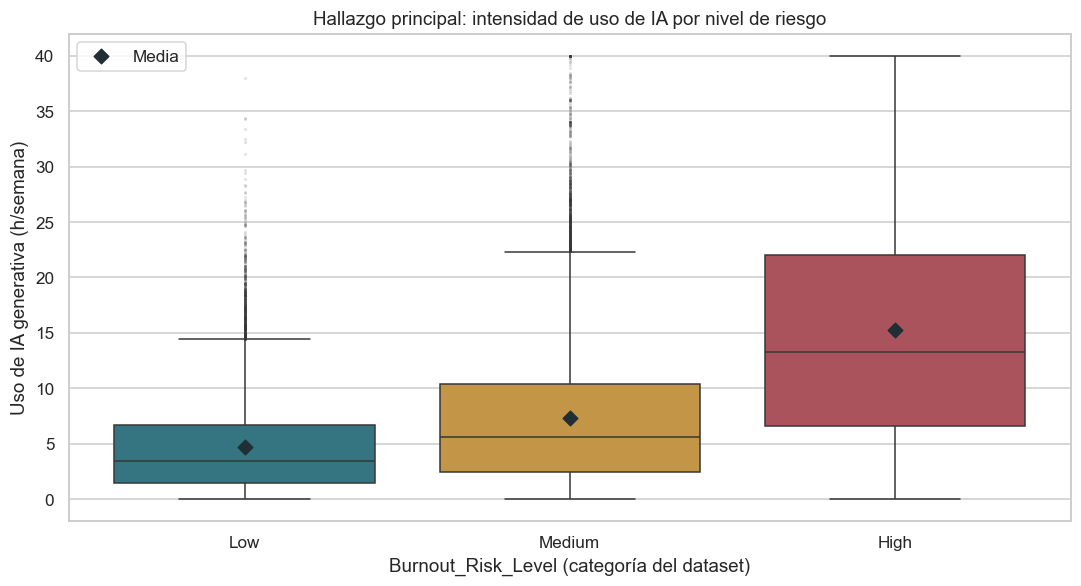

**Hallazgo sustentado:** High presenta media **15,215 h/semana** y Low **4,644**, diferencia **10,571 h/semana**. Las medianas High y Low son 13,25 y 3,41. La diferencia aparece también en las medianas y el gráfico muestra dispersión y solapamiento: las horas no identifican por sí solas la categoría individual. Este perfil es pertinente para el objetivo de comprender características asociadas con High, sin afirmar causalidad o detección anticipada.

,Mínimo,Máximo
Burnout_Risk_Level,,
Low,"0,000","38,000"
Medium,"0,000","40,000"
High,"0,000","40,000"


Burnout_Risk_Level,Low,Medium,High,Total
Weekly_GenAI_Hours,,,,
"[0, 5)",10.525,9.681,2.361,22.567
"[5, 10)",4.046,5.828,2.308,12.182
"[10, 20)",1.672,4.473,4.097,10.242
"[20, ∞)",126,1.162,3.721,5.009


Burnout_Risk_Level,Low,Medium,High
Weekly_GenAI_Hours,,,
"[0, 5)","46,639","42,899","10,462"
"[5, 10)","33,213","47,841","18,946"
"[10, 20)","16,325","43,673","40,002"
"[20, ∞)","2,515","23,198","74,286"


**Construcción de la etiqueta:** las bandas son intervalos exploratorios declarados, no umbrales recuperados del generador. El solapamiento y la coexistencia de clases en las bandas no prueban ni descartan que horas, dependencia, ansiedad u otras variables hayan intervenido en la etiqueta. Sin fórmula, código generador o validación original, la incertidumbre permanece. Un futuro modelo podría aprender reglas de generación del archivo; su desempeño no acreditaría por sí solo utilidad clínica o institucional.

In [19]:
hallazgo = pd.DataFrame({'n': grupos.size().reindex(CLASES),
                        'Media IA (h/semana)': medias_grupo.Weekly_GenAI_Hours,
                        'Mediana IA (h/semana)': medianas_grupo.Weekly_GenAI_Hours,
                        'Q1': grupos.Weekly_GenAI_Hours.quantile(.25).reindex(CLASES),
                        'Q3': grupos.Weekly_GenAI_Hours.quantile(.75).reindex(CLASES)})
diferencia_high_low = medias_grupo.loc['High', 'Weekly_GenAI_Hours'] - medias_grupo.loc['Low', 'Weekly_GenAI_Hours']
tabla(hallazgo, 6)
fig, ax = plt.subplots(figsize=(10, 5.5))
sns.boxplot(data=df, x='Burnout_Risk_Level', y='Weekly_GenAI_Hours', hue='Burnout_Risk_Level',
            order=CLASES, hue_order=CLASES, palette=PALETA, legend=False,
            flierprops={'marker': '.', 'markersize': 2, 'alpha': .15}, ax=ax)
ax.scatter(range(3), hallazgo['Media IA (h/semana)'], color='#202F35', marker='D', s=45, zorder=5, label='Media')
ax.set(title='Hallazgo principal: intensidad de uso de IA por nivel de riesgo',
       xlabel='Burnout_Risk_Level (categoría del dataset)', ylabel='Uso de IA generativa (h/semana)')
ax.legend()
fig.tight_layout()
plt.show()
texto(f'**Hallazgo sustentado:** High presenta media **{es(hallazgo.loc["High", "Media IA (h/semana)"], 3)} h/semana** '
      f'y Low **{es(hallazgo.loc["Low", "Media IA (h/semana)"], 3)}**, diferencia **{es(diferencia_high_low, 3)} h/semana**. '
      f'Las medianas High y Low son {es(hallazgo.loc["High", "Mediana IA (h/semana)"])} y '
      f'{es(hallazgo.loc["Low", "Mediana IA (h/semana)"])}. '
      'La diferencia aparece también en las medianas y el gráfico muestra dispersión y solapamiento: '
      'las horas no identifican por sí solas la categoría individual. Este perfil es pertinente para '
      'el objetivo de comprender características asociadas con High, sin afirmar causalidad o detección anticipada.')

# Comprobación descriptiva de solapamiento y sensibilidad, sin ajustar modelos ni reconstruir una regla.
tabla(grupos.Weekly_GenAI_Hours.agg(Mínimo='min', Máximo='max').reindex(CLASES))
limites_horas = [0, 5, 10, 20, np.inf]
bandas_horas = pd.cut(df.Weekly_GenAI_Hours, bins=limites_horas, right=False,
                     labels=['[0, 5)', '[5, 10)', '[10, 20)', '[20, ∞)'])
conteos_bandas = pd.crosstab(bandas_horas, df.Burnout_Risk_Level, dropna=False).reindex(columns=CLASES, fill_value=0)
tabla(conteos_bandas.assign(Total=conteos_bandas.sum(axis=1)), 0)
tabla(100 * conteos_bandas.div(conteos_bandas.sum(axis=1), axis=0))
texto('**Construcción de la etiqueta:** las bandas son intervalos exploratorios declarados, no umbrales recuperados del generador. '
      'El solapamiento y la coexistencia de clases en las bandas no prueban ni descartan que horas, dependencia, ansiedad u otras '
      'variables hayan intervenido en la etiqueta. Sin fórmula, código generador o validación original, la incertidumbre permanece. '
      'Un futuro modelo podría aprender reglas de generación del archivo; su desempeño no acreditaría por sí solo utilidad clínica o institucional.')


## 11. Decisiones concretas para la Fase 3

| Tema | Acción que debe resolver la preparación de datos |
|---|---|
| Identificador | Conservar `Student_ID` para trazabilidad; excluirlo de predictores, correlaciones sustantivas y escalado. |
| Nulos y duplicados | Usar la auditoría calculada; no imputar ni deduplicar por rutina si no hay incidencias. Si cambia el CSV, repetir controles antes de decidir. |
| Diccionario y categorías | Alinear el nombre con sufijo `(1)` y documentar `Summarizing_Reading` / `Direct_Answer_Generation`. Aplicar cambios de escritura solo con equivalencia semántica confirmada. |
| Variables nominales | Usar one-hot para las cinco columnas categóricas, incluidas `Year_of_Study` y `Prompt_Engineering_Skill`, sin imponer distancias; aprender categorías dentro del entrenamiento en fases posteriores. |
| Variables ordinales | Confirmar orden Beginner–Intermediate–Advanced en `Prompt_Engineering_Skill`. Revisar `Year_of_Study`: Graduate no es automáticamente un año adicional. Mantener dependencia y ansiedad como escalas ordenadas y confirmar su instrumento. |
| Variable booleana y conteo | Proponer representación binaria de `Paid_Subscription`; confirmar definición de `Tool_Diversity` como conteo discreto. |
| Objetivo | Preservar Low, Medium y High como clases multiclase; cualquier codificación de etiqueta debe mantener los nombres para interpretación y evaluación. |
| Disponibilidad temporal | Excluir `Post_Semester_GPA` de una eventual predicción anterior al cierre del semestre. Revisar `Skill_Retention_Score`, `Anxiety_Level_During_Exams` y las variables de hábitos según sus momentos de medición; no asumir que estaban disponibles anticipadamente. |
| Fuga de información | Obtener fórmula y variables generadoras de la etiqueta. Distinguir reproducción de reglas del dataset, información contemporánea y fuga temporal antes de aprobar predictores. Cualquier cambio de GPA derivado hereda la temporalidad del GPA final. |
| Extremos IQR | Revisar horas altas de IA y estudio, dependencia 10, GPA bajos y retención baja con instrumentos y unidades. Conservar inicialmente los extremos plausibles; documentar cualquier tratamiento futuro y comprobar si afecta desproporcionadamente a High. |
| Distribución de clases | Planificar particiones posteriores que preserven clases; no aplicar sobremuestreo automáticamente. Evaluar macro F1 y precision/recall/F1 por clase, con atención especial a High; el KPI descriptivo permanece separado. |
| Procedencia y compatibilidad | URL, publicador, versión y licencia están verificados. Confirmar autor científico/recolección, fecha original de descarga, instrumentos y método de generación. Mantener las correcciones documentales trazables. |

No se realiza aquí limpieza definitiva, eliminación de outliers, codificación del dataset final,
escalado, partición de entrenamiento/prueba ni entrenamiento de modelos.


In [20]:
# Resumen final generado desde los cálculos de esta ejecución.
tabla(calidad_resumen, 0)
tabla(distribucion)
texto(f'**Cierre de Fase 2:** fuente `{RUTA_CSV.as_posix()}`; {es(len(df), 0)} registros y '
      f'{df.shape[1]} variables. KPI High **{es(kpi, 3)} %**. '
      f'{len(discrepancias_medias)} discrepancias de medias por grupo a precisión publicada. '
      f'{int(mascara_iqr.any(axis=1).sum())} registros distintos marcados por IQR, conservados. '
      'El hallazgo principal compara distribuciones de horas de IA por riesgo y no constituye diagnóstico, '
      'efecto causal ni capacidad de detección anticipada. Las decisiones de preparación se detallan en la tabla anterior.')

# Invariantes de esta fase: ninguna columna/fila original se transformó o eliminó.
assert tuple(df.columns) == columnas_originales
assert df.shape == forma_original
assert np.array_equal(pd.util.hash_pandas_object(df, index=True).values, firma_dataframe)
assert hashlib.sha256((RAIZ / RUTA_CSV).read_bytes()).hexdigest() == huella_csv
print('Integridad verificada: CSV y dataframe original sin modificaciones.')
print('Celdas ejecutadas en orden: el resumen usa únicamente variables creadas en este notebook.')


,Comprobación,Cantidad
0,Celdas nulas (pandas),0
1,Campos vacíos / solo espacios (CSV),0
2,Filas duplicadas completas excedentes,0
3,Identificadores únicos no nulos,50.000
4,Student_ID repetidos excedentes,0
5,Filas participantes en ID repetido,0
6,Registros con objetivo ausente,0
7,Registros con objetivo inesperado,0


,Cantidad,Porcentaje de todas las filas
Burnout_Risk_Level,,
Low,16.369,"32,738"
Medium,21.144,"42,288"
High,12.487,"24,974"


**Cierre de Fase 2:** fuente `dataset/ai_student_impact_dataset (1).csv`; 50.000 registros y 16 variables. KPI High **24,974 %**. 0 discrepancias de medias por grupo a precisión publicada. 3269 registros distintos marcados por IQR, conservados. El hallazgo principal compara distribuciones de horas de IA por riesgo y no constituye diagnóstico, efecto causal ni capacidad de detección anticipada. Las decisiones de preparación se detallan en la tabla anterior.

Integridad verificada: CSV y dataframe original sin modificaciones.
Celdas ejecutadas en orden: el resumen usa únicamente variables creadas en este notebook.
